# Dark-matter quantum-sensor response analysis

Forward + inverse analysis of the detector response, organised **by detector**
and, within each, **by velocity-distribution model**. Same pipeline throughout
(load Mathematica response matrix -> forward model `exposure * M @ eta` ->
recover the monotone non-negative flux `x(v_min)`); only two things change:

- **detector** (`material`): **TES (Al)** -- Mermin, 0.1 eV threshold, fine `R10`;
  **MKID (TiN)** -- Lindhard, 0.2 eV threshold, fine `R9`.
- **velocity model**: **Halo** -- standard halo (SHM, `v0=238, ve=250, vesc=544`
  km/s); **pure dark disk** -- same DM density, colder (`v0=70, ve=100,
  vesc=694`). The actual **best-fit uses a mixture** `eta = (1-p)*Halo + p*Disk`
  with disk fraction `p`; because both components carry the same local DM
  density, the mixture's density equals 100% SHM for any `p`. A third model,
  **Bound** (Earth-captured thermal DM), is a separate dense population
  (`rho_b`, isotropic, `vesc=11.2` km/s) -- only the heaviest mass (1 GeV) has
  any signal, since the bound DM is too slow to reach higher `v_min`.

The mixture sections sweep `p` over `DISK_FRACTIONS` and overlay, on each fit,
the **100% SHM** halo and the **`p` x pure disk** component for reference.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from quantum_sensor import DarkMatterQuantumAnalysis, RunConfig

MASS_LABELS = {'1': '10 MeV', '2': '100 MeV', '3': '1 GeV'}
DETECTOR = {'Al': 'TES', 'TiN': 'MKID'}
# Dark-disk mixing fractions p for the best-fit eta = (1-p)*Halo + p*Disk.
DISK_FRACTIONS = (0.05, 0.25)


def run_masses(material, q='0', nbins=5, eta='Halo', background='none',
               disk_fraction=None, masses=('1', '2', '3'), solver='osqp', save=True):
    """Run the forward+inverse analysis for several DM masses.

    Shows one combined figure (the masses side by side). When ``save=True``
    (default) each run is ALSO saved on its own -- flux.csv plus an individual
    flux.pdf -- into its per-run folder
    results/<DET>/bkg-<background>/<material>_q<q>_M<mass>_R<nbins>_<eta>/, so
    every type is stored separately regardless of the combined display.
    """
    fig, axes = plt.subplots(1, len(masses), figsize=(6 * len(masses), 5), squeeze=False)
    for ax, mass in zip(axes[0], masses):
        a = DarkMatterQuantumAnalysis(
            RunConfig(material=material, q=q, mass=mass, nbins=nbins,
                      eta=eta, disk_fraction=disk_fraction, background=background))
        flux = a.optimize(solver=solver)
        print('signal     :', a.signal)
        print('background :', a.background)

        if save:
            a.save_flux()                     # flux.csv in this run's own folder
            sfig, sax = plt.subplots(figsize=(8, 6))
            a.plot(save=True, ax=sax)         # individual flux.pdf next to the CSV
            plt.close(sfig)                   # keep only the combined figure on screen

        a.plot(save=False, ax=ax)             # combined panel (display only)
        ax.set_title(f'{material} ({DETECTOR[material]}), $m_\\chi$ = {MASS_LABELS[mass]}',
                     fontsize=13)
        print(f'{material} q{q} M{mass} R{nbins}: {a.n_ebins} E-bins x '
              f'{a.n_vmin} v_min bins, peak flux {flux.max():.2e}')
    model = eta if disk_fraction is None else f'mix {round(disk_fraction*100)}% disk'
    fig.suptitle(f'{material} ({DETECTOR[material]}), q{q}, R{nbins}, {model}, bkg={background}',
                 fontsize=14)
    plt.tight_layout(); plt.show()


# TES (Al)

## Halo (SHM) — reference

### Heavy mediator (q0), 5 energy bins

signal     : [1570.79084605 3131.55127409 4545.98363397 5778.84476157 6904.24601238]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_Halo/flux.pdf
Al q0 M1 R5: 5 E-bins x 109 v_min bins, peak flux 7.94e+02
signal     : [175.59968906 388.49532734 591.3064205  767.03249245 949.6015802 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_Halo/flux.pdf
Al q0 M2 R5: 5 E-bins x 83 v_min bins, peak flux 8.26e+01
signal     : [19.01138846 38.04699488 56.47029094 75.90665275 96.13045555]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_Halo/flux.pdf
Al q0 M3 R5: 5 E-bins x 89 v_min bins, peak flux 8.28e+00


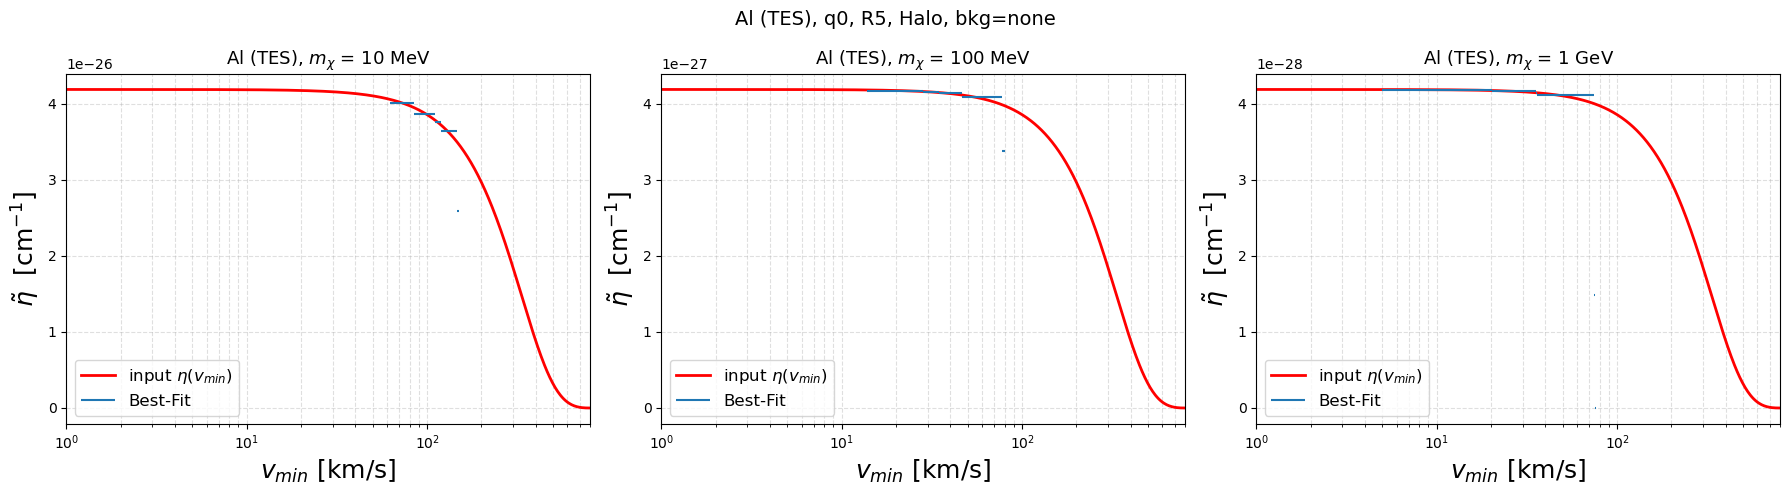

In [2]:
run_masses('Al', q='0', nbins=5, eta='Halo', solver = 'scipy')

### Light mediator (q2), 5 energy bins

signal     : [1643.04667179 2804.4100599  3275.14588277 3706.82145117 4010.26416688]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_Halo/flux.pdf
Al q2 M1 R5: 5 E-bins x 152 v_min bins, peak flux 7.99e+02
signal     : [140.75104142 277.03908008 408.42210454 525.42000921 623.44158222]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_Halo/flux.pdf
Al q2 M2 R5: 5 E-bins x 331 v_min bins, peak flux 8.36e+01
signal     : [14.83351792 29.2563884  42.4065896  53.85091848 63.27704233]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_Halo/flux.pdf
Al q2 M3 R5: 5 E-bins x 362 v_min bins, peak flux 8.53e+00


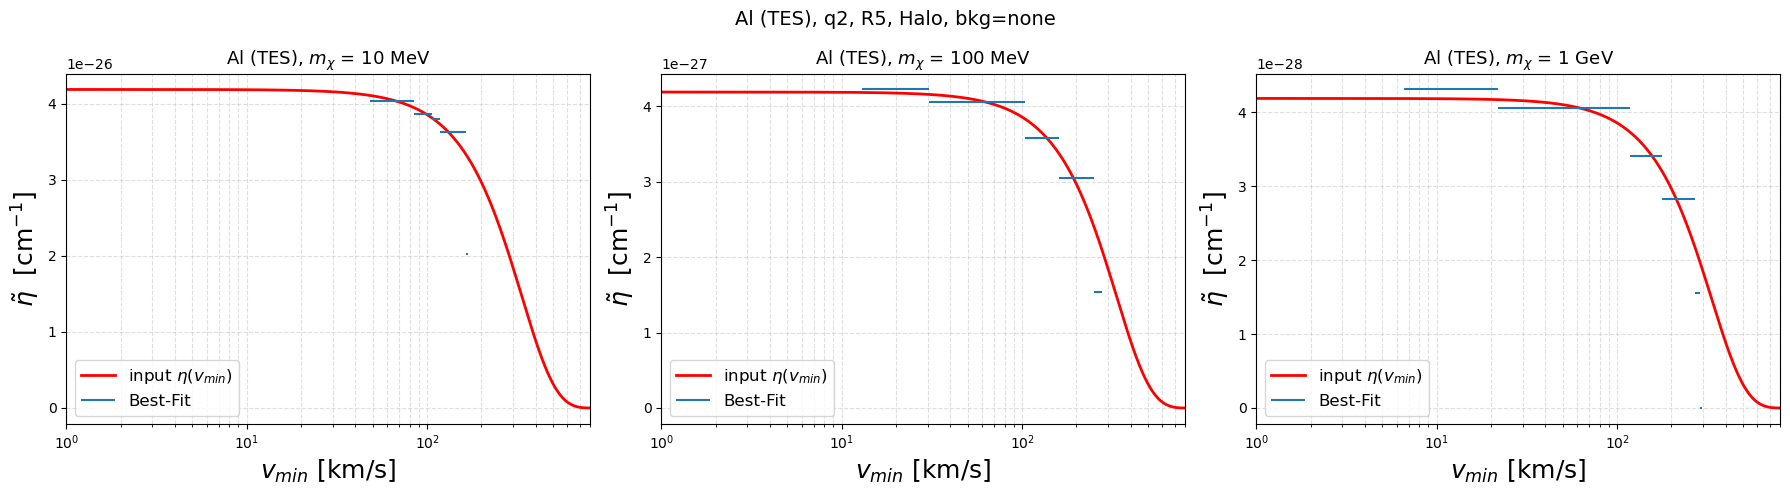

In [3]:
run_masses('Al', q='2', nbins=5, eta='Halo', solver = 'osqp')

### Heavy mediator (q0), 10 energy bins

signal     : [ 614.77087127 1045.05735503 1448.7431919  1862.24306974 2187.43751118
 2567.37860544 2896.47819683 3164.38980559 3452.21394833 3696.09012043]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_Halo/flux.pdf
Al q0 M1 R10: 10 E-bins x 118 v_min bins, peak flux 8.00e+02
signal     : [ 62.30327794 107.46658519 165.99503585 216.69039418 268.68725266
 325.78025342 373.53108553 415.35165428 462.67341633 511.65404684]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_Halo/flux.pdf
Al q0 M2 R10: 10 E-bins x 84 v_min bins, peak flux 8.27e+01
signal     : [ 7.30033107 12.12925987 16.5551219  20.80744999 25.85569028 31.0738261
 36.3591632  41.66914205 47.11842551 52.17870831]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Quant

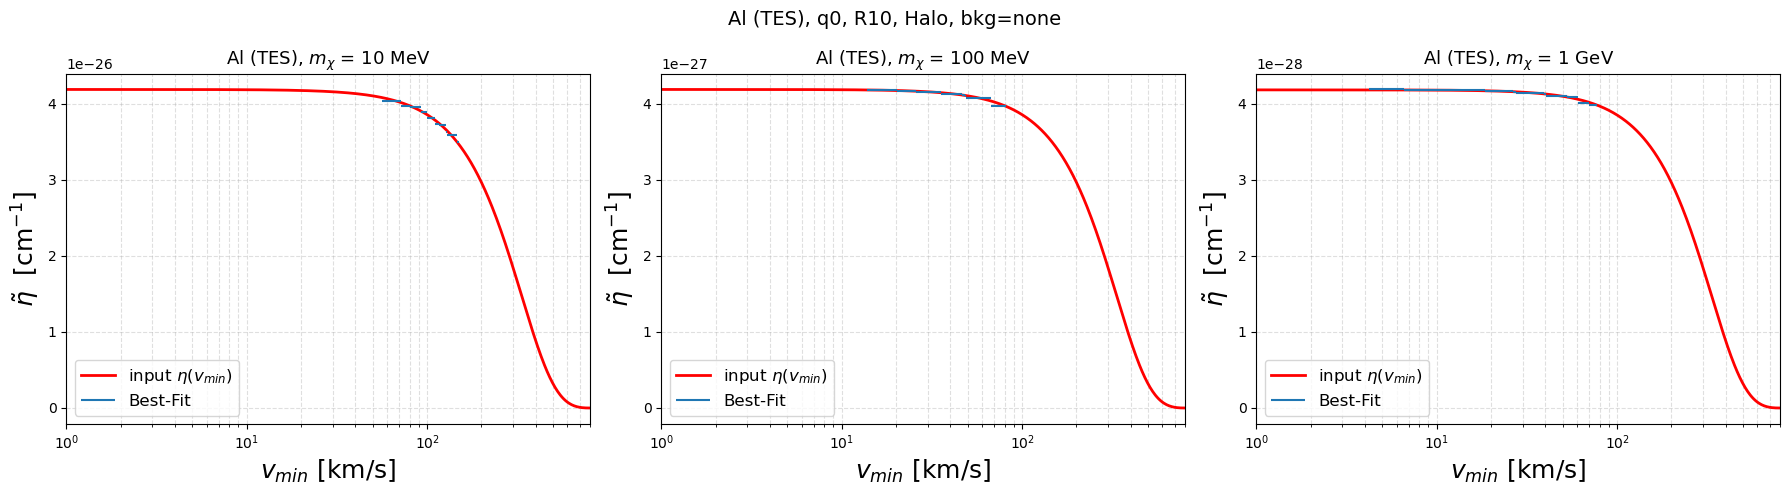

In [4]:
run_masses('Al', q='0', nbins=10, eta='Halo', solver = 'scipy')

### Light mediator (q2), 10 energy bins

signal     : [ 632.25893654  991.07216268 1242.5016891  1489.60464742 1616.6118016
 1635.20806933 1588.10902248 1701.57592657 1884.5038921  1864.8961758 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_Halo/flux.pdf
Al q2 M1 R10: 10 E-bins x 150 v_min bins, peak flux 8.08e+02
signal     : [ 50.08260968  86.43753816 123.02057605 159.78971123 195.20073368
 229.00543168 259.91287554 288.3560401  314.41795476 337.37700175]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_Halo/flux.pdf
Al q2 M2 R10: 10 E-bins x 348 v_min bins, peak flux 8.25e+01
signal     : [ 5.73289418  9.78601172 13.53218825 17.16837543 20.57899294 23.84230676
 26.81855843 29.54124325 32.03028776 34.22197212]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Quan

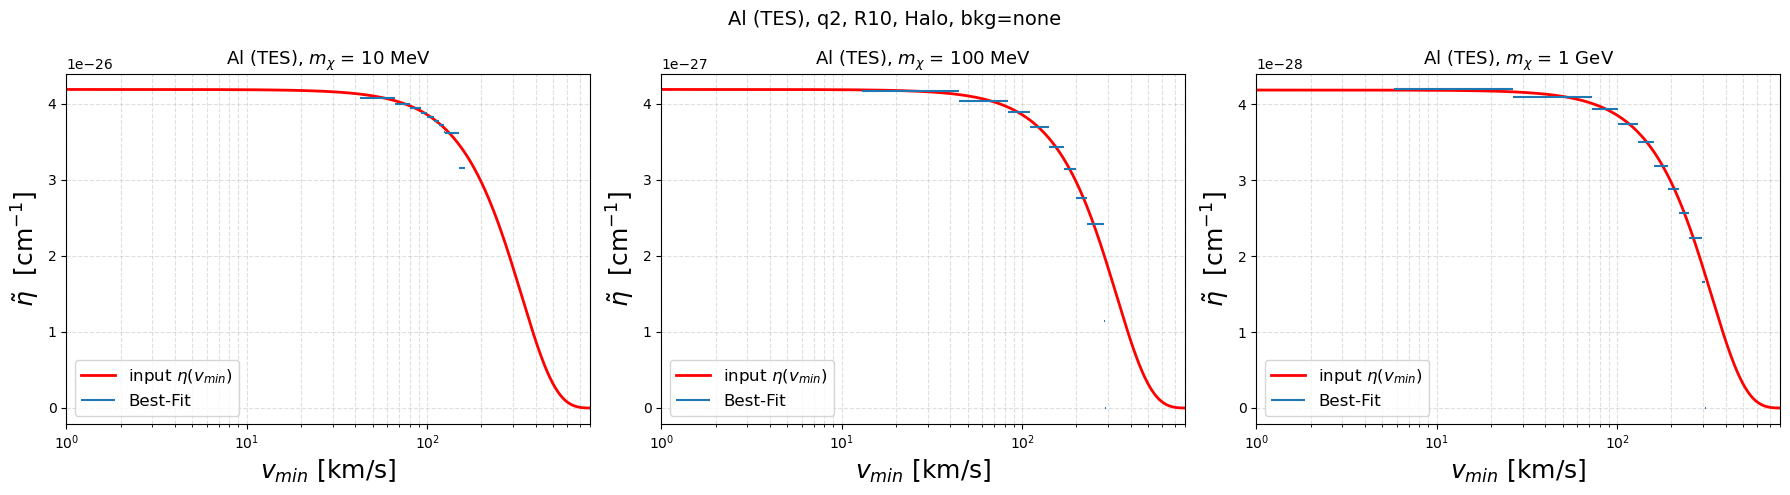

In [5]:
run_masses('Al', q='2', nbins=10, eta='Halo', solver = 'scipy')

## Mixture (best-fit) — sweep dark-disk fraction

`eta = (1-p)*Halo + p*Disk`. Each figure overlays 100% SHM (gray) and `p` x pure disk (green).

### Heavy mediator (q0), 5 energy bins

signal     : [1628.43904635 3207.54195201 4594.4683309  5765.74475241 6809.51166562]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_mix5/flux.pdf
Al q0 M1 R5: 5 E-bins x 109 v_min bins, peak flux 8.37e+02
signal     : [ 190.56941369  420.36853965  637.42988919  823.46177149 1014.05918049]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_mix5/flux.pdf
Al q0 M2 R5: 5 E-bins x 83 v_min bins, peak flux 8.96e+01
signal     : [ 20.66353001  41.30084765  61.17000615  81.9566499  103.31733508]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_mix5/flux.pdf
Al q0 M3 R5: 5 E-bins x 89 v_min bins, peak flux 9.00e+00


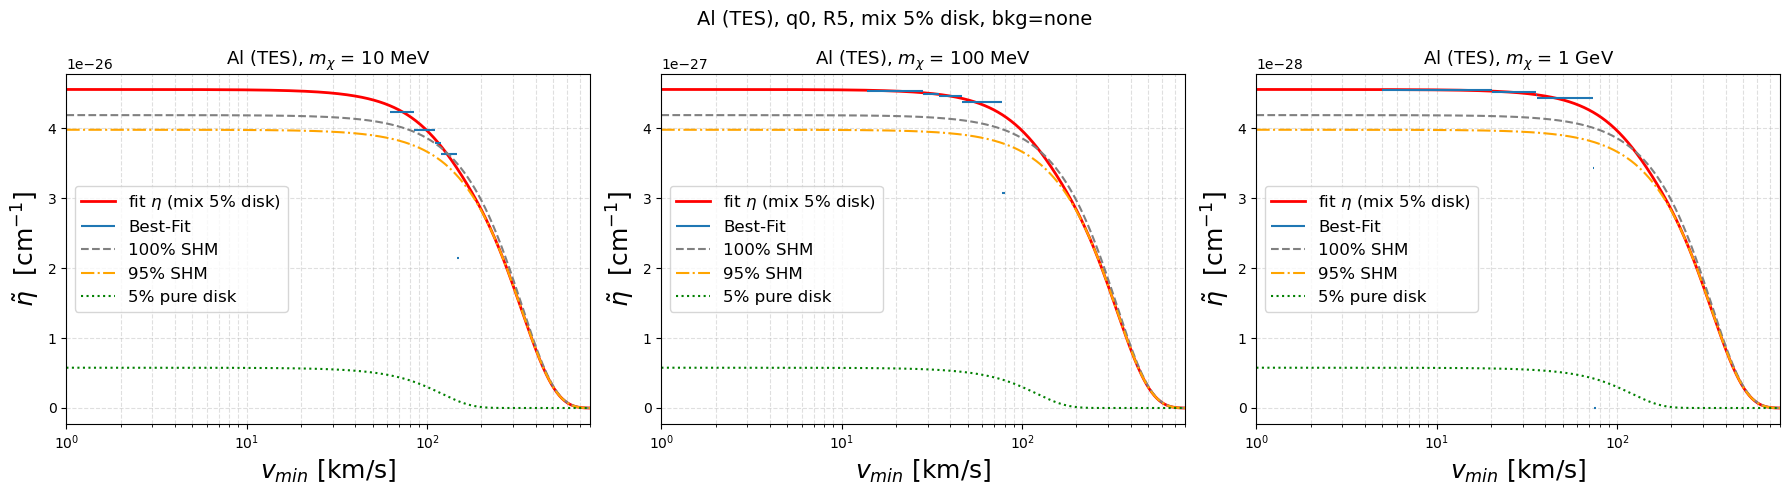

signal     : [1859.03184752 3511.50466368 4788.40711864 5713.34471575 6430.57427858]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_mix25/flux.pdf
Al q0 M1 R5: 5 E-bins x 109 v_min bins, peak flux 1.01e+03
signal     : [ 250.44831222  547.86138889  821.92376391 1049.17888767 1271.88958168]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_mix25/flux.pdf
Al q0 M2 R5: 5 E-bins x 83 v_min bins, peak flux 1.18e+02
signal     : [ 27.27209618  54.31625872  79.96886702 106.15663852 132.06485318]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_mix25/flux.pdf
Al q0 M3 R5: 5 E-bins x 89 v_min bins, peak flux 1.19e+01


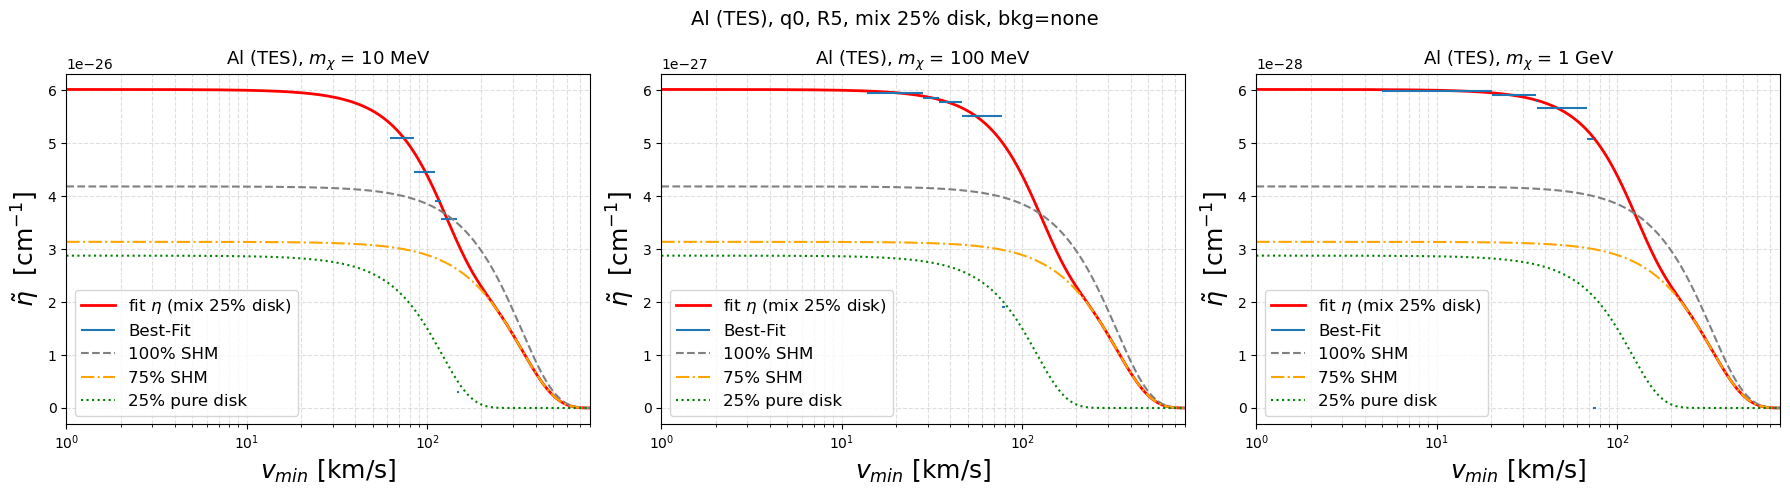

In [6]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='0', nbins=5, disk_fraction=p, solver = 'scipy')

### Light mediator (q2), 5 energy bins

signal     : [1735.92071069 2899.54174195 3321.95045687 3694.0921165  3940.18942825]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_mix5/flux.pdf
Al q2 M1 R5: 5 E-bins x 152 v_min bins, peak flux 8.47e+02
signal     : [152.28856044 295.92737215 427.49399024 539.06030737 629.64755549]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_mix5/flux.pdf
Al q2 M2 R5: 5 E-bins x 331 v_min bins, peak flux 9.14e+01
signal     : [16.0509384  31.21664504 44.35237835 55.30575562 64.05240333]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_mix5/flux.pdf
Al q2 M3 R5: 5 E-bins x 362 v_min bins, peak flux 9.44e+00


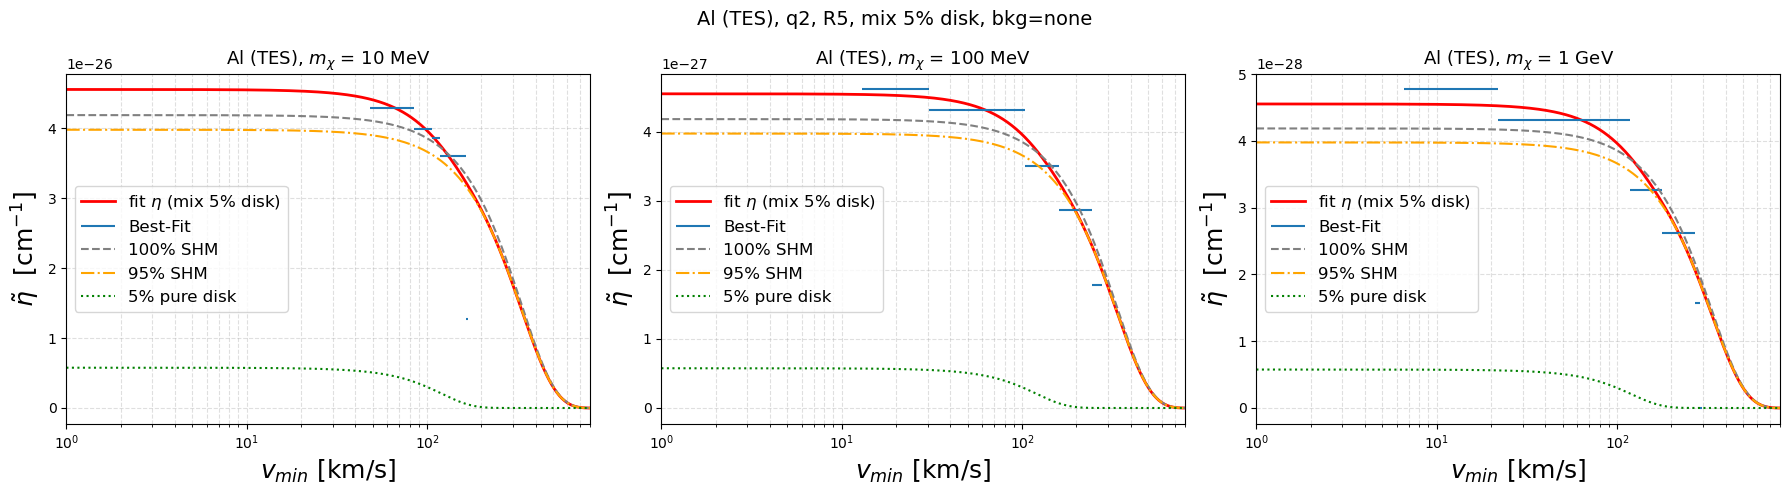

signal     : [2107.41686628 3280.06847015 3509.16875326 3643.17477778 3659.89047373]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_mix25/flux.pdf
Al q2 M1 R5: 5 E-bins x 152 v_min bins, peak flux 1.04e+03
signal     : [198.43863649 371.48054046 503.78153306 593.62150002 654.47144854]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_mix25/flux.pdf
Al q2 M2 R5: 5 E-bins x 331 v_min bins, peak flux 1.23e+02
signal     : [20.92062033 39.05767158 52.13553339 61.12510418 67.15384734]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_mix25/flux.pdf
Al q2 M3 R5: 5 E-bins x 362 v_min bins, peak flux 1.31e+01


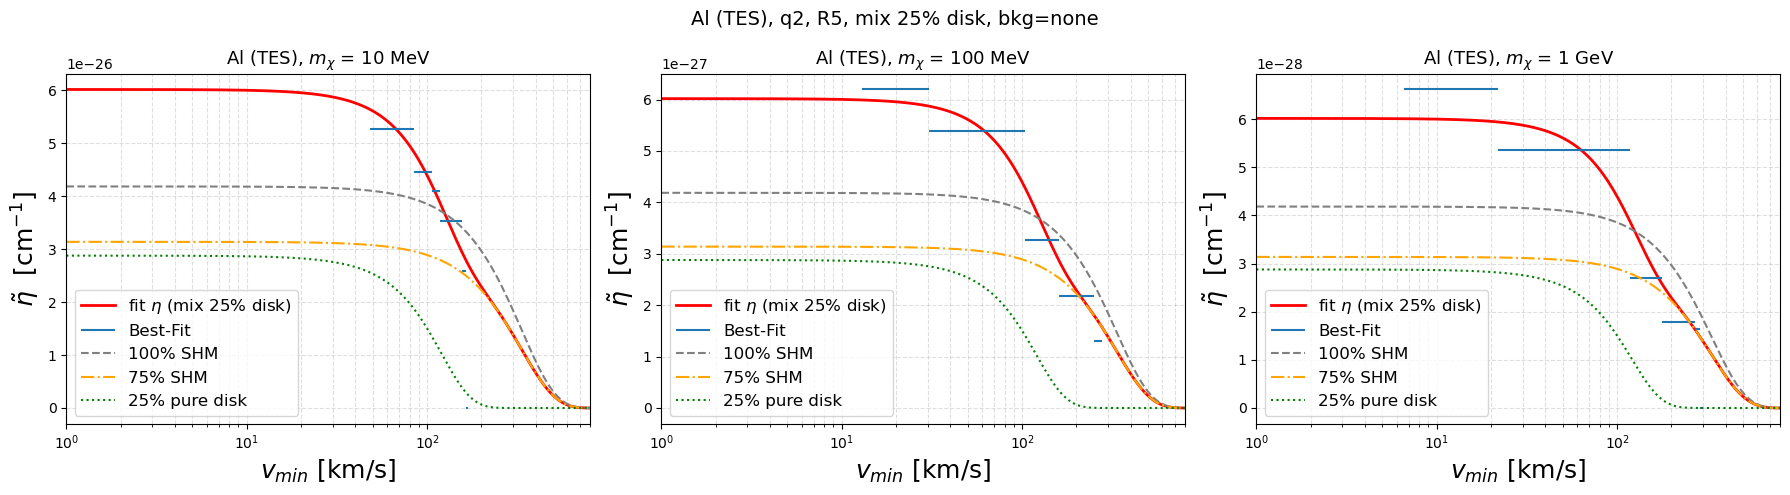

In [7]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='2', nbins=5, disk_fraction=p)

### Heavy mediator (q0), 10 energy bins

signal     : [ 639.9710247  1081.68556174 1490.05233095 1902.96805248 2219.79864531
 2587.46766209 2899.99829768 3148.57161917 3414.92702108 3636.69709854]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_mix5/flux.pdf
Al q0 M1 R10: 10 E-bins x 118 v_min bins, peak flux 8.51e+02
signal     : [ 67.66319809 116.58547954 179.80812362 234.34052137 290.04057102
 350.95479488 401.54781531 445.50707434 494.96650081 545.78667493]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_mix5/flux.pdf
Al q0 M2 R10: 10 E-bins x 84 v_min bins, peak flux 8.98e+01
signal     : [ 7.9367935  13.18140154 17.98096964 22.58227226 28.03147111 33.64466824
 39.30219707 44.95557213 50.71927896 56.02417745]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Quan

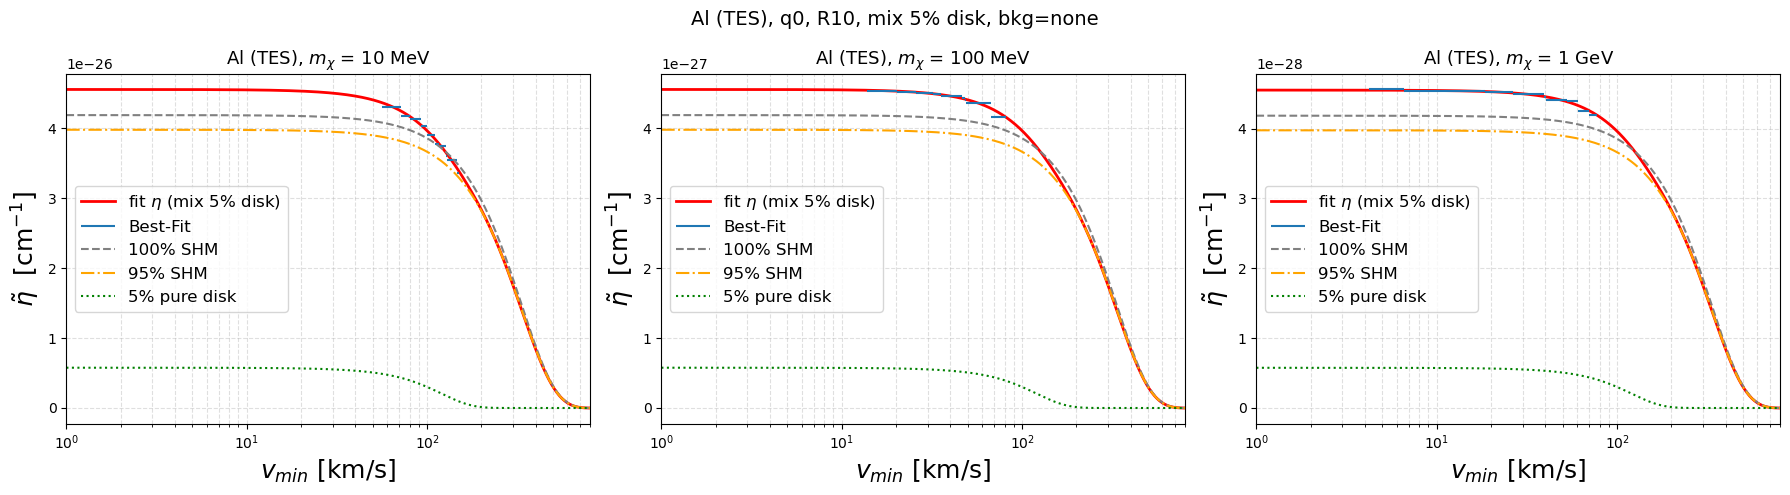

signal     : [ 740.77163844 1228.19838855 1655.28888711 2065.86798344 2349.24318185
 2667.82388868 2914.07870108 3085.29887347 3265.77931207 3399.125011  ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_mix25/flux.pdf
Al q0 M1 R10: 10 E-bins x 118 v_min bins, peak flux 1.05e+03
signal     : [ 89.10287868 153.06105694 235.0604747  304.94103013 375.45384445
 451.65296072 513.61473445 566.12875458 624.13883873 682.31718729]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_mix25/flux.pdf
Al q0 M2 R10: 10 E-bins x 84 v_min bins, peak flux 1.18e+02
signal     : [10.48264319 17.38996821 23.68436057 29.68156137 36.73459443 43.92803684
 51.07433255 58.10129245 65.12269276 71.40605402]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Qu

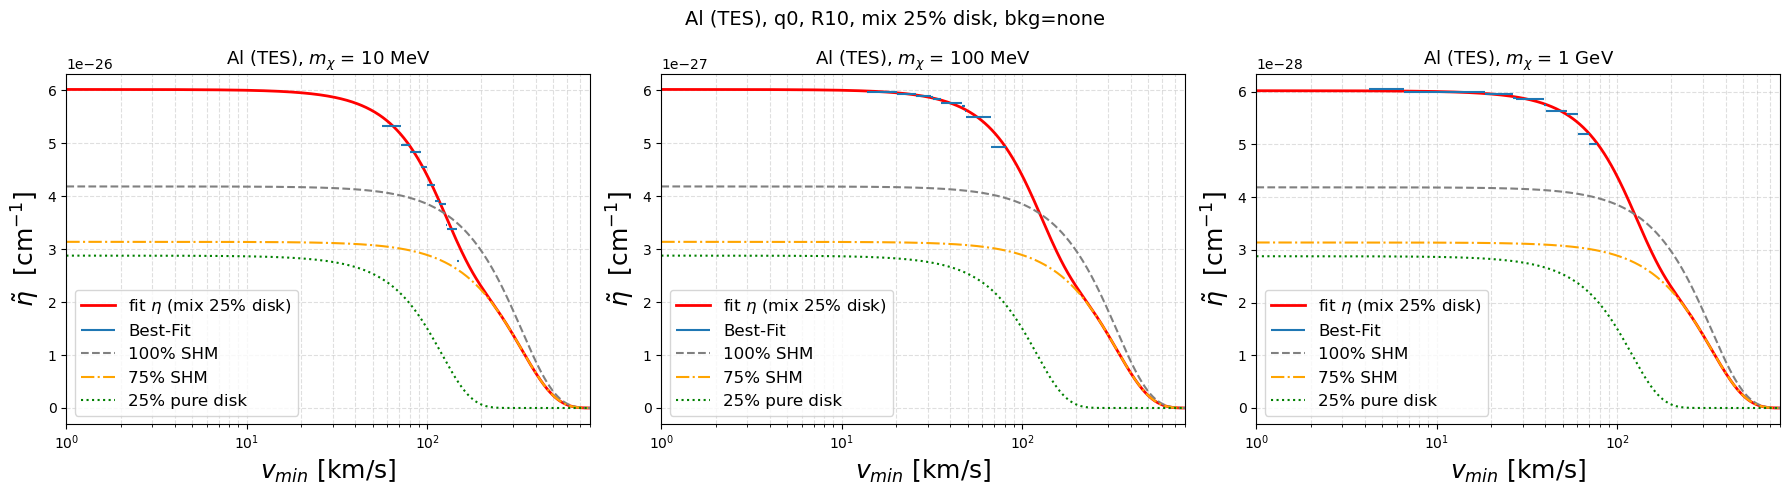

In [8]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='0', nbins=10, disk_fraction=p, solver = 'scipy')

### Light mediator (q2), 10 energy bins

signal     : [ 674.0414194  1044.57203585 1294.53537957 1534.13833807 1648.8798087
 1653.33940907 1593.38579132 1693.7188085  1860.24091646 1830.80247471]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_mix5/flux.pdf
Al q2 M1 R10: 10 E-bins x 150 v_min bins, peak flux 8.64e+02
signal     : [ 54.33088145  93.42144868 132.12711826 170.10078784 205.60324367
 238.57186726 267.99598377 294.62574731 318.70596987 339.61455514]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_mix5/flux.pdf
Al q2 M2 R10: 10 E-bins x 348 v_min bins, peak flux 8.95e+01
signal     : [ 6.21880335 10.56764605 14.50743275 18.23585988 21.63722896 24.81806424
 27.66118703 30.22098815 32.53055091 34.53382616]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Quan

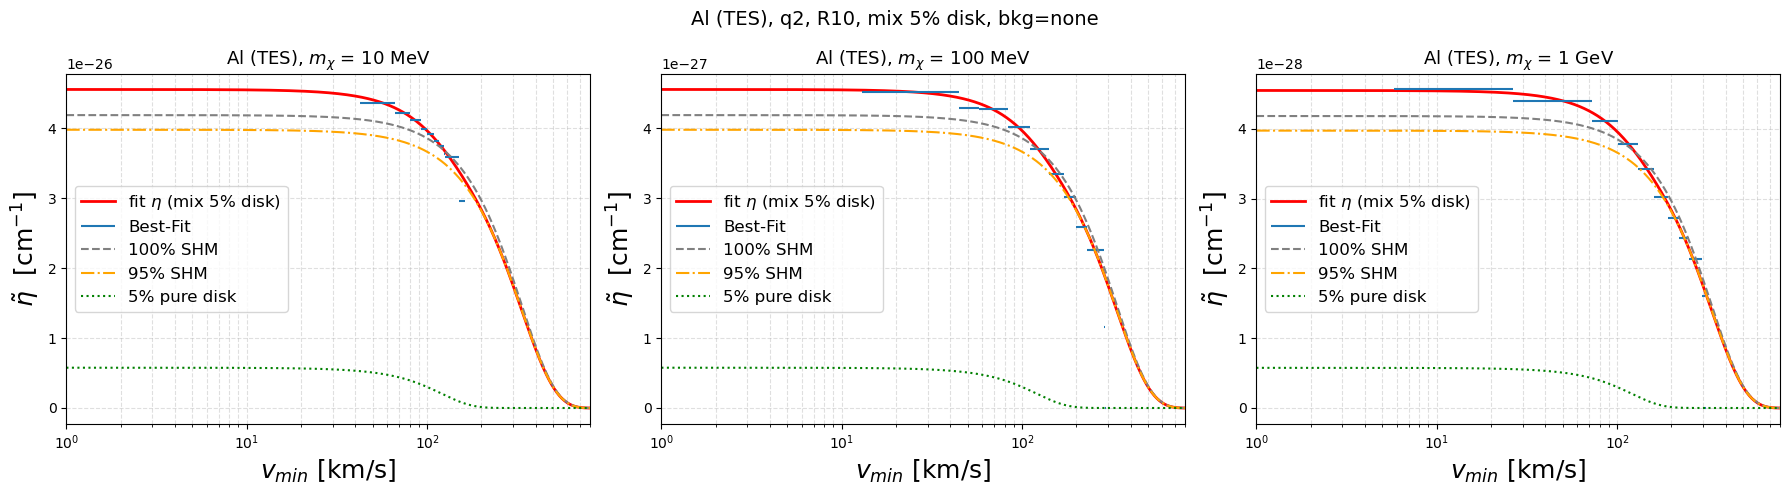

signal     : [ 841.17135084 1258.57152849 1502.67014147 1712.27310069 1777.95183708
 1725.86476805 1614.49286665 1662.29033623 1763.18901391 1694.42767034]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_mix25/flux.pdf
Al q2 M1 R10: 10 E-bins x 150 v_min bins, peak flux 1.09e+03
signal     : [ 71.32396854 121.35709077 168.55328712 211.34509428 247.21328363
 276.83760959 300.32841669 319.70457615 335.85803032 348.5647687 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_mix25/flux.pdf
Al q2 M2 R10: 10 E-bins x 348 v_min bins, peak flux 1.18e+02
signal     : [ 8.16244    13.69418336 18.40841076 22.50579765 25.87017306 28.72109417
 31.03170146 32.93996777 34.53160349 35.78124229]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Q

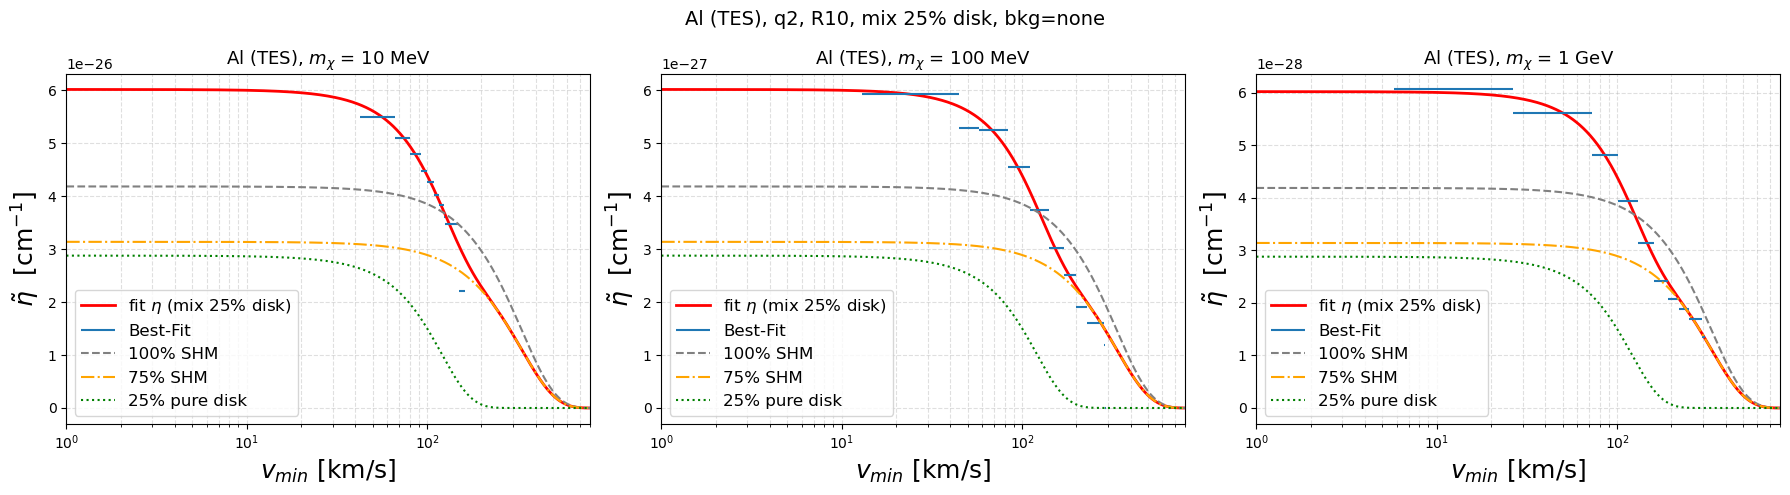

In [9]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='2', nbins=10, disk_fraction=p)

## Bound (Earth-bound thermal DM)

Dense (`rho_b = 1e14` GeV/cm^3), isotropic, cold (`v0 ~ 2.16` km/s at 1 GeV), `vesc = 11.2` km/s. Only **M3 (1 GeV)** is shown: the bound population is too slow to reach the `v_min` thresholds of the lighter masses (M1/M2 have no signal).

### Heavy mediator (q0), 5 energy bins

signal     : [8.91882711e+13 1.43131778e+11 1.08175850e+08 7.59066527e+01
 9.61304556e+01]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_Bound/flux.pdf
Al q0 M3 R5: 5 E-bins x 89 v_min bins, peak flux 1.46e+14


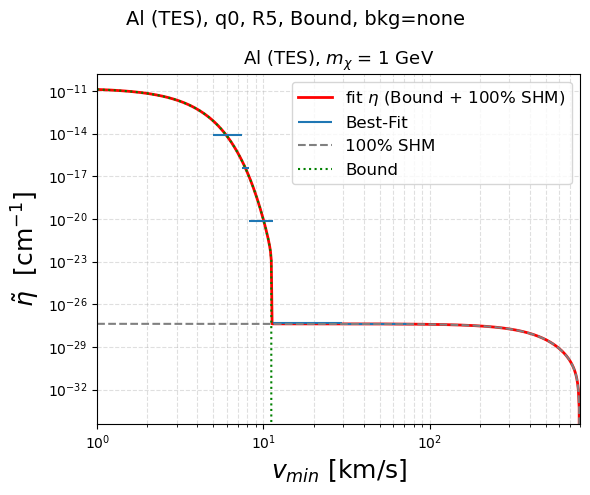

In [10]:
run_masses('Al', q='0', nbins=5, eta='Bound', masses=('3',))

### Light mediator (q2), 5 energy bins

signal     : [6.56805817e+10 2.92563884e+01 4.24065896e+01 5.38509185e+01
 6.32770423e+01]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_Bound/flux.pdf
Al q2 M3 R5: 5 E-bins x 362 v_min bins, peak flux 1.89e+11


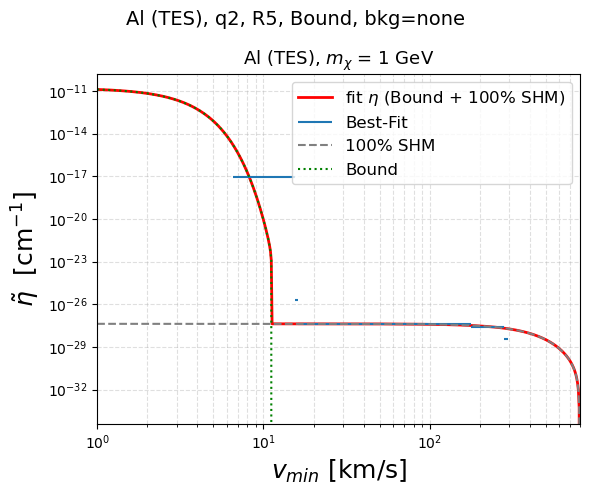

In [11]:
run_masses('Al', q='2', nbins=5, eta='Bound', masses=('3',))

### Heavy mediator (q0), 10 energy bins

signal     : [1.49538291e+14 7.97823278e+12 1.62192218e+11 5.38149323e+09
 1.06702888e+08 2.05917651e+06 3.63591632e+01 4.16691420e+01
 4.71184255e+01 5.21787083e+01]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R10_Bound/flux.pdf
Al q0 M3 R10: 10 E-bins x 92 v_min bins, peak flux 1.03e+15


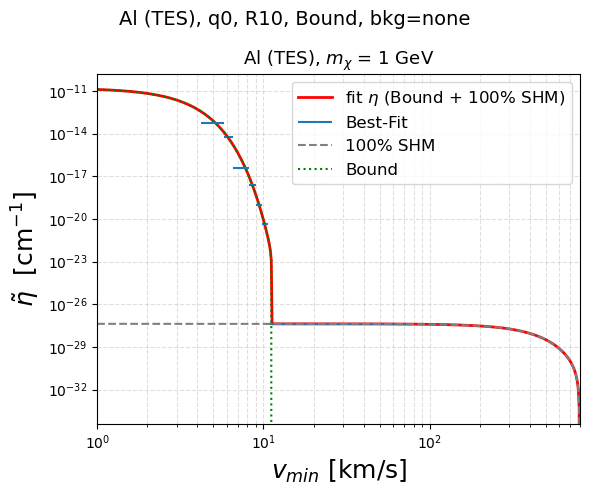

In [12]:
run_masses('Al', q='0', nbins=10, eta='Bound', masses=('3',))

### Light mediator (q2), 10 energy bins

signal     : [2.59912553e+11 1.01660757e+04 1.35321883e+01 1.71683754e+01
 2.05789929e+01 2.38423068e+01 2.68185584e+01 2.95412432e+01
 3.20302878e+01 3.42219721e+01]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R10_Bound/flux.pdf
Al q2 M3 R10: 10 E-bins x 381 v_min bins, peak flux 2.66e+12


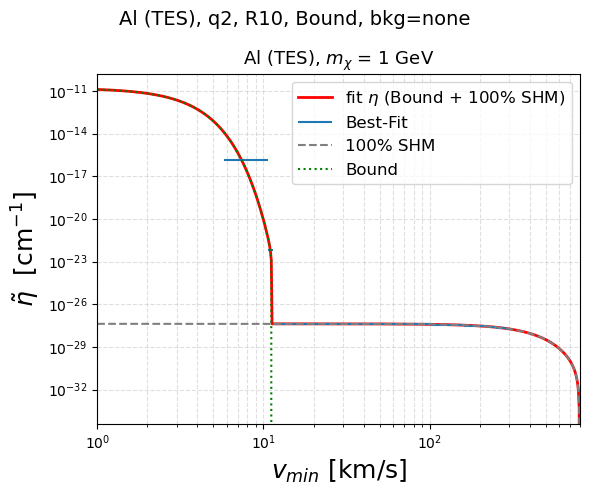

In [13]:
run_masses('Al', q='2', nbins=10, eta='Bound', masses=('3',))

## With a background scenario (Halo)

signal     : [1570.79084605 3131.55127409 4545.98363397 5778.84476157 6904.24601238]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q0 M1 R5: 5 E-bins x 109 v_min bins, peak flux 7.94e+02
signal     : [175.59968906 388.49532734 591.3064205  767.03249245 949.6015802 ]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q0 M2 R5: 5 E-bins x 83 v_min bins, peak flux 8.26e+01
signal     : [19.01138846 38.04699488 56.47029094 75.90665275 96.13045555]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q0 M3 R5: 5 E-bins x 89 v_min bins, peak flux 8.28e+00


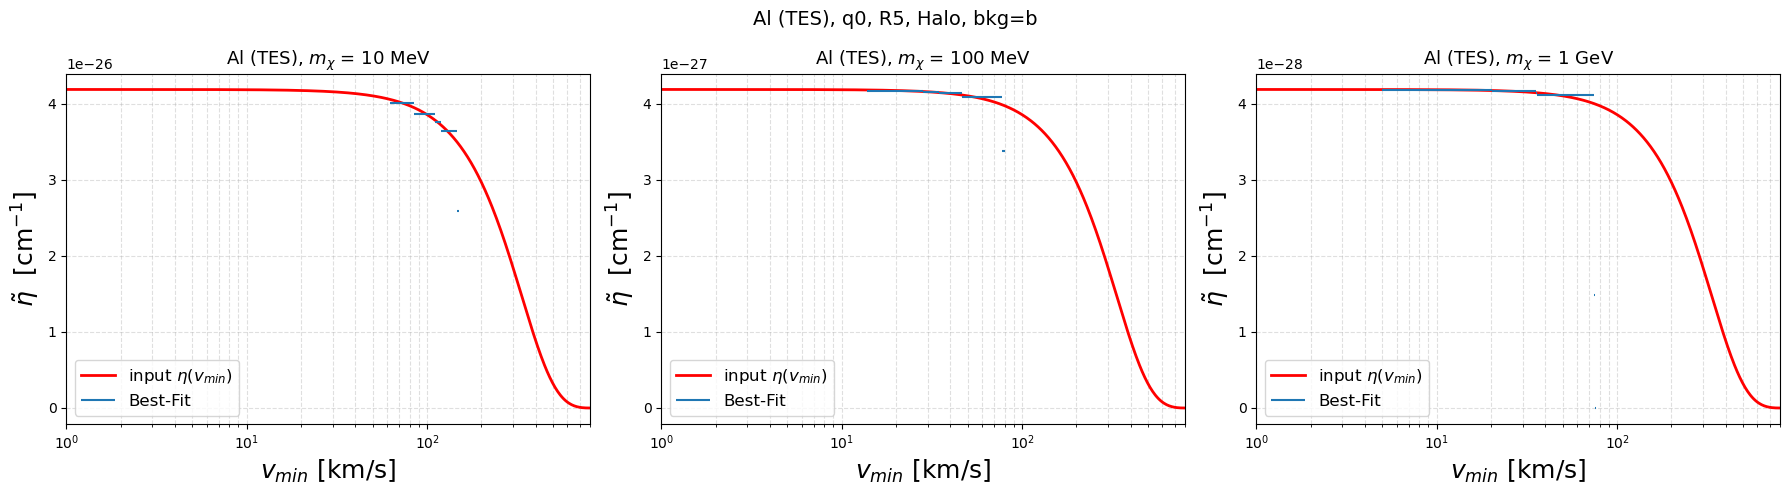

In [14]:
run_masses('Al', q='0', nbins=5, eta='Halo', background='b', solver = 'scipy', save = False)

signal     : [1643.04667179 2804.4100599  3275.14588277 3706.82145117 4010.26416688]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q2 M1 R5: 5 E-bins x 152 v_min bins, peak flux 7.99e+02
signal     : [140.75104142 277.03908008 408.42210454 525.42000921 623.44158222]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q2 M2 R5: 5 E-bins x 331 v_min bins, peak flux 8.36e+01
signal     : [14.83351792 29.2563884  42.4065896  53.85091848 63.27704233]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q2 M3 R5: 5 E-bins x 362 v_min bins, peak flux 8.53e+00


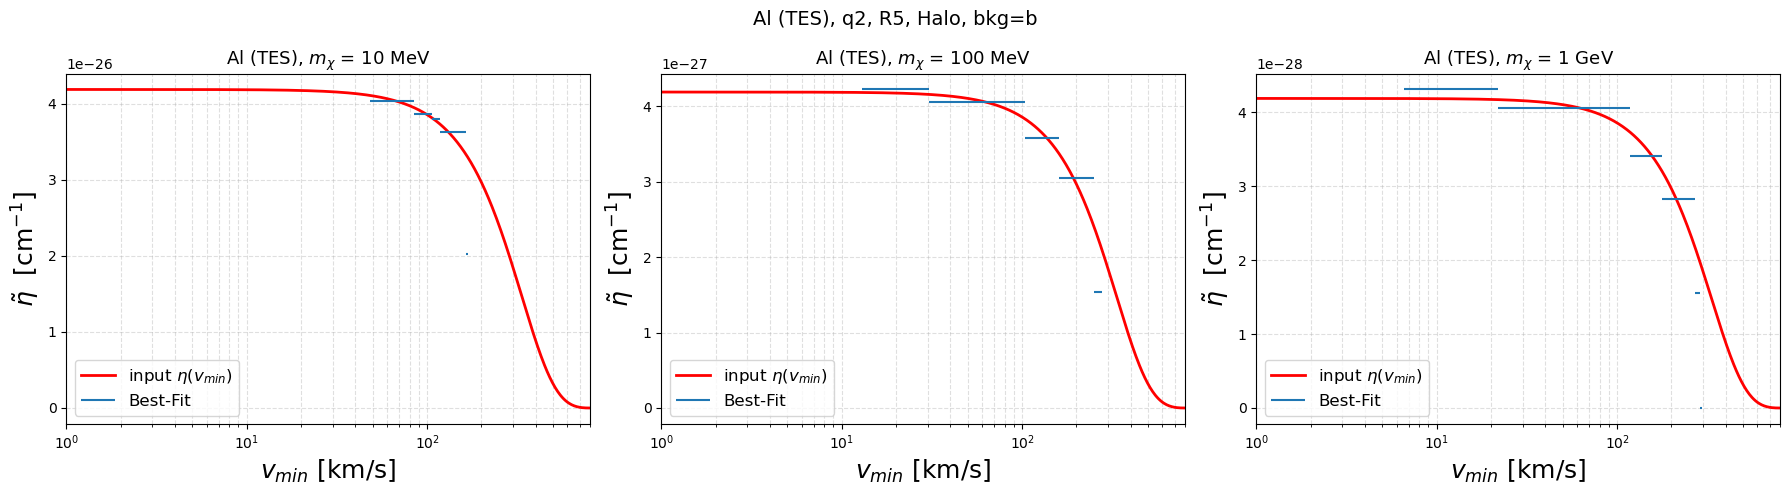

In [15]:
run_masses('Al', q='2', nbins=5, eta='Halo', background='b', save = False)

signal     : [1570.79084605 3131.55127409 4545.98363397 5778.84476157 6904.24601238]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q0 M1 R5: 5 E-bins x 109 v_min bins, peak flux 7.94e+02
signal     : [175.59968906 388.49532734 591.3064205  767.03249245 949.6015802 ]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q0 M2 R5: 5 E-bins x 83 v_min bins, peak flux 8.26e+01
signal     : [19.01138846 38.04699488 56.47029094 75.90665275 96.13045555]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q0 M3 R5: 5 E-bins x 89 v_min bins, peak flux 8.28e+00


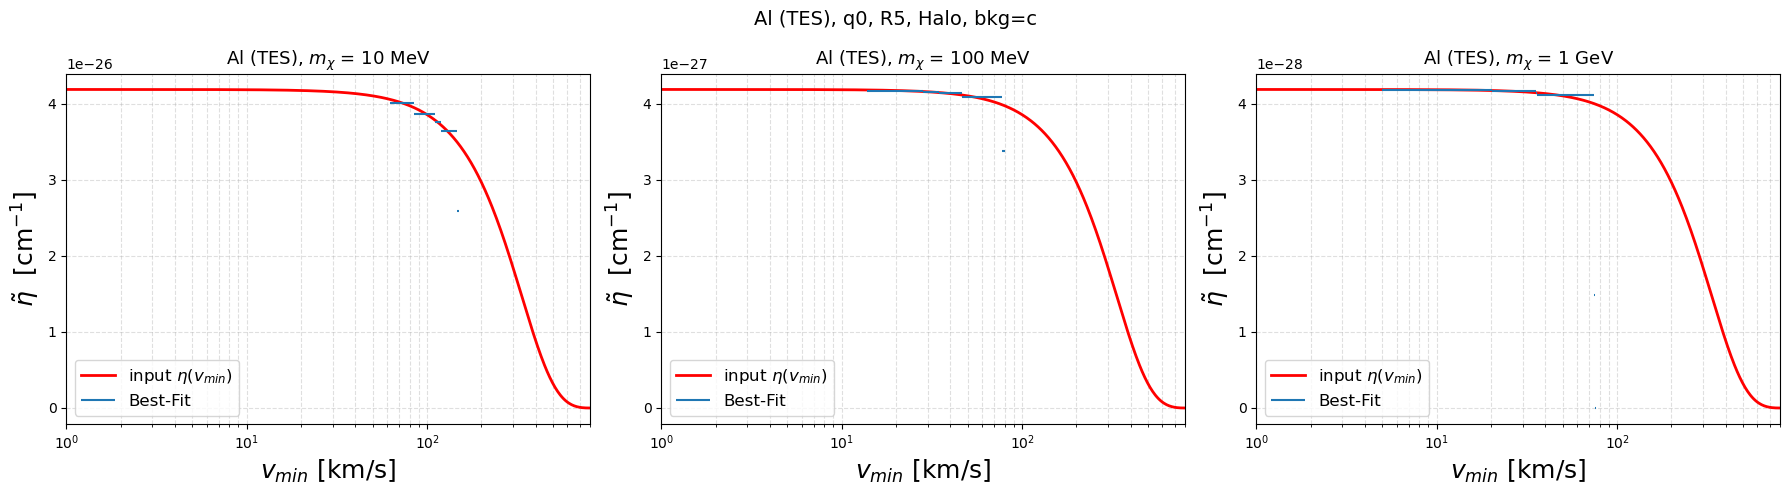

In [16]:
run_masses('Al', q='0', nbins=5, eta='Halo', background='c', solver = 'scipy', save = False)

signal     : [1643.04667179 2804.4100599  3275.14588277 3706.82145117 4010.26416688]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q2 M1 R5: 5 E-bins x 152 v_min bins, peak flux 7.99e+02
signal     : [140.75104142 277.03908008 408.42210454 525.42000921 623.44158222]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q2 M2 R5: 5 E-bins x 331 v_min bins, peak flux 8.36e+01
signal     : [14.83351792 29.2563884  42.4065896  53.85091848 63.27704233]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q2 M3 R5: 5 E-bins x 362 v_min bins, peak flux 8.53e+00


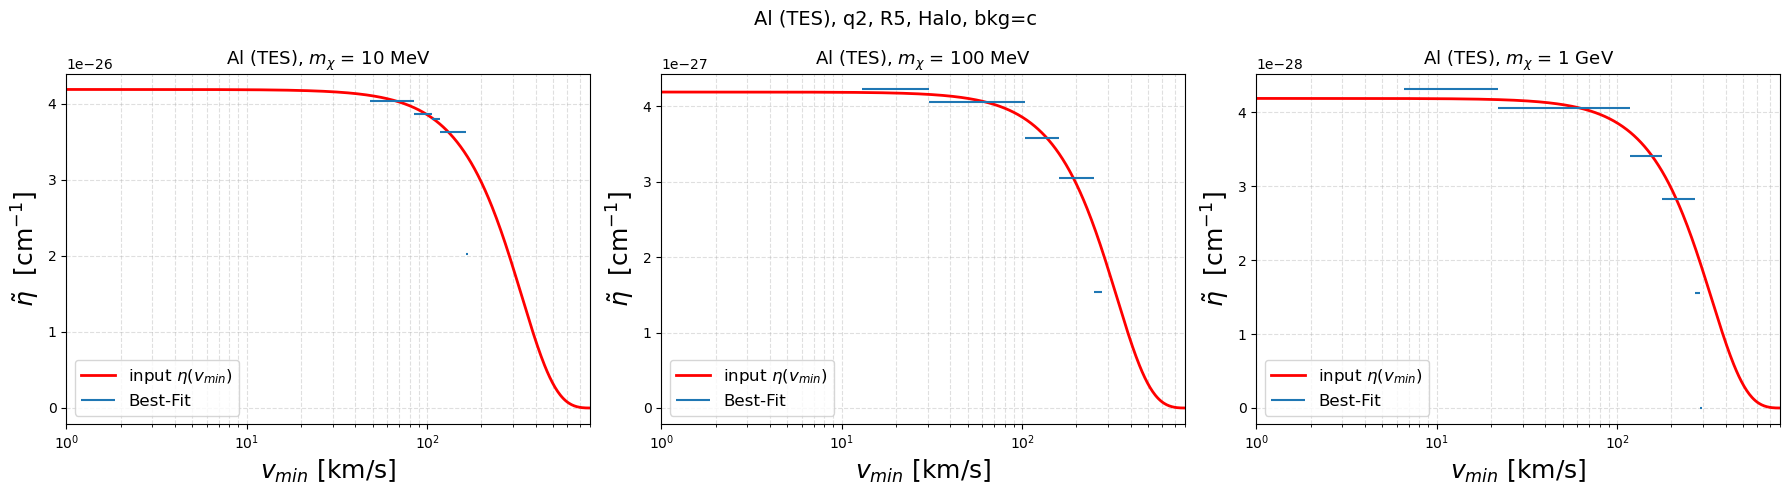

In [17]:
run_masses('Al', q='2', nbins=5, eta='Halo', background='c', save = False)

# MKID (TiN)

Titanium-nitride detector, Lindhard dielectric. Threshold **0.2 eV** (bins start at 0.2 eV, fine binning **`R9`**). Heavy mediator (`q0`) only so far.

## Halo (SHM) — reference

### Heavy mediator (q0), 5 energy bins

signal     : [1244.83775278 3729.12863001 5174.9531436  6443.26980099 7699.28826551]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_Halo/flux.pdf
TiN q0 M1 R5: 5 E-bins x 128 v_min bins, peak flux 7.93e+02
signal     : [112.37865277 342.93597888 493.66688293 637.60524329 771.35315068]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_Halo/flux.pdf
TiN q0 M2 R5: 5 E-bins x 141 v_min bins, peak flux 8.25e+01
signal     : [11.04759812 33.88975177 49.08103761 63.48564757 77.074123  ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_Halo/flux.pdf
TiN q0 M3 R5: 5 E-bins x 144 v_min bins, peak flux 8.28e+00


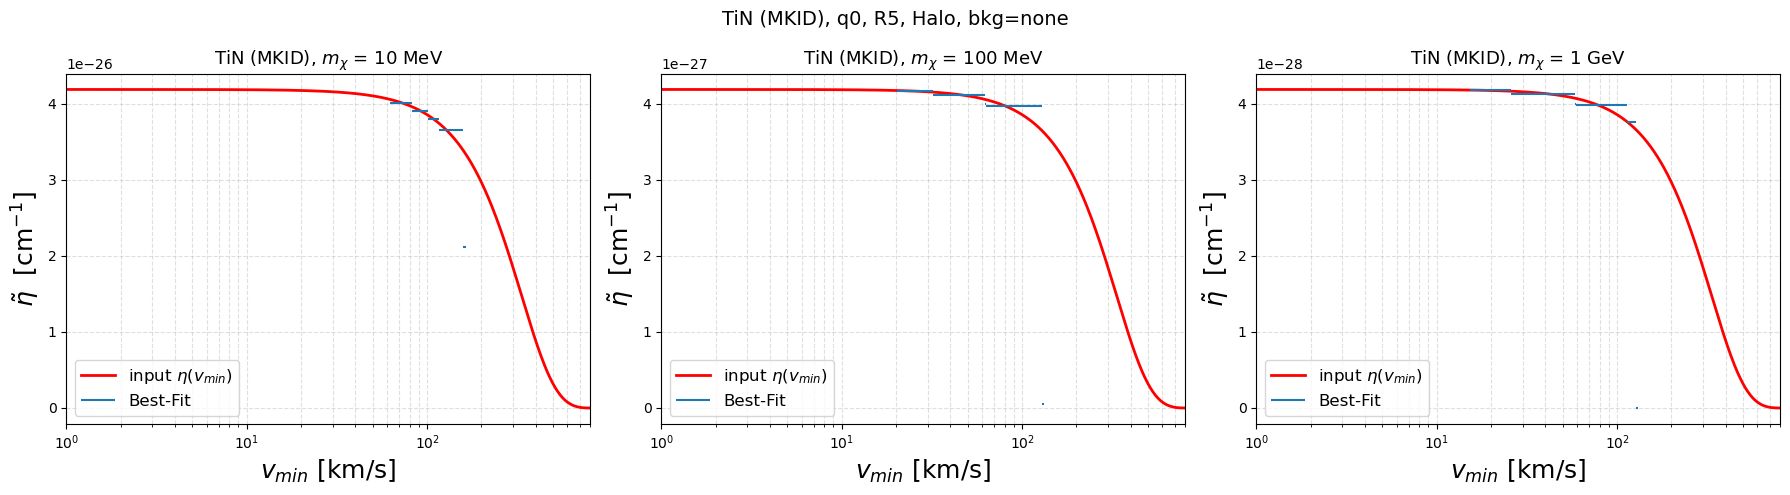

In [18]:
run_masses('TiN', q='0', nbins=5, eta='Halo', solver = 'scipy')

### Light mediator (q2), 5 energy bins

signal     : [ 6112.7758042  17977.45352933 22127.87663029 30916.40771885
 35584.61414784]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R5_Halo/flux.pdf
TiN q2 M1 R5: 5 E-bins x 328 v_min bins, peak flux 7.93e+02
signal     : [ 675.98310096 2029.73504143 2822.78738159 3408.26705596 3781.74910347]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R5_Halo/flux.pdf
TiN q2 M2 R5: 5 E-bins x 482 v_min bins, peak flux 8.80e+01
signal     : [ 69.84601451 205.52552054 284.27976593 341.95568268 378.6826884 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_Halo/flux.pdf
TiN q2 M3 R5: 5 E-bins x 500 v_min bins, peak flux 9.04e+00


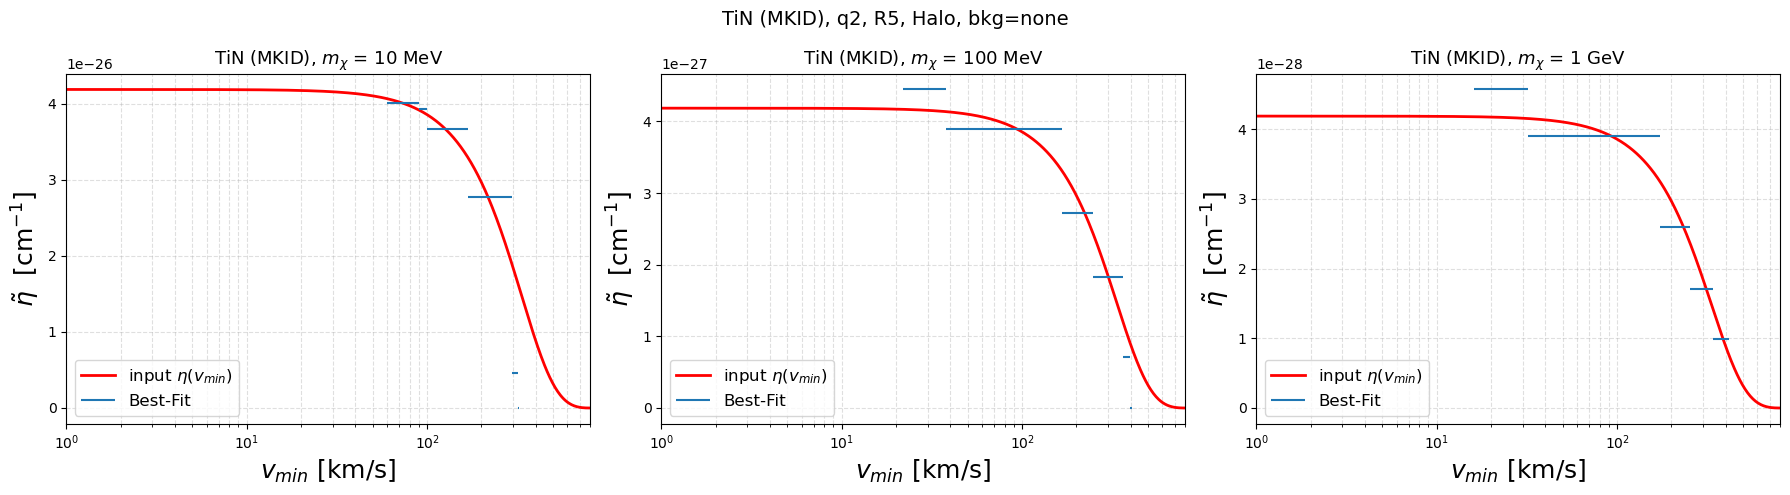

In [19]:
run_masses('TiN', q='2', nbins=5, eta='Halo')

### Heavy mediator (q0), 9 energy bins

signal     : [1244.83775278 1699.15450925 2086.80176179 2459.20351997 2767.80408127
 3149.58410426 3486.79290771 3832.79372248 4143.96897587]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_Halo/flux.pdf
TiN q0 M1 R9: 9 E-bins x 132 v_min bins, peak flux 7.93e+02
signal     : [112.37865277 153.52244956 193.34303799 232.3712228  271.74099254
 309.83659627 347.1668202  382.89280999 416.98651253]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_Halo/flux.pdf
TiN q0 M2 R9: 9 E-bins x 146 v_min bins, peak flux 8.24e+01
signal     : [11.04759812 15.13646878 19.2011237  23.14861029 27.07572805 30.88873182
 34.62615854 38.21000439 41.67883699]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-non

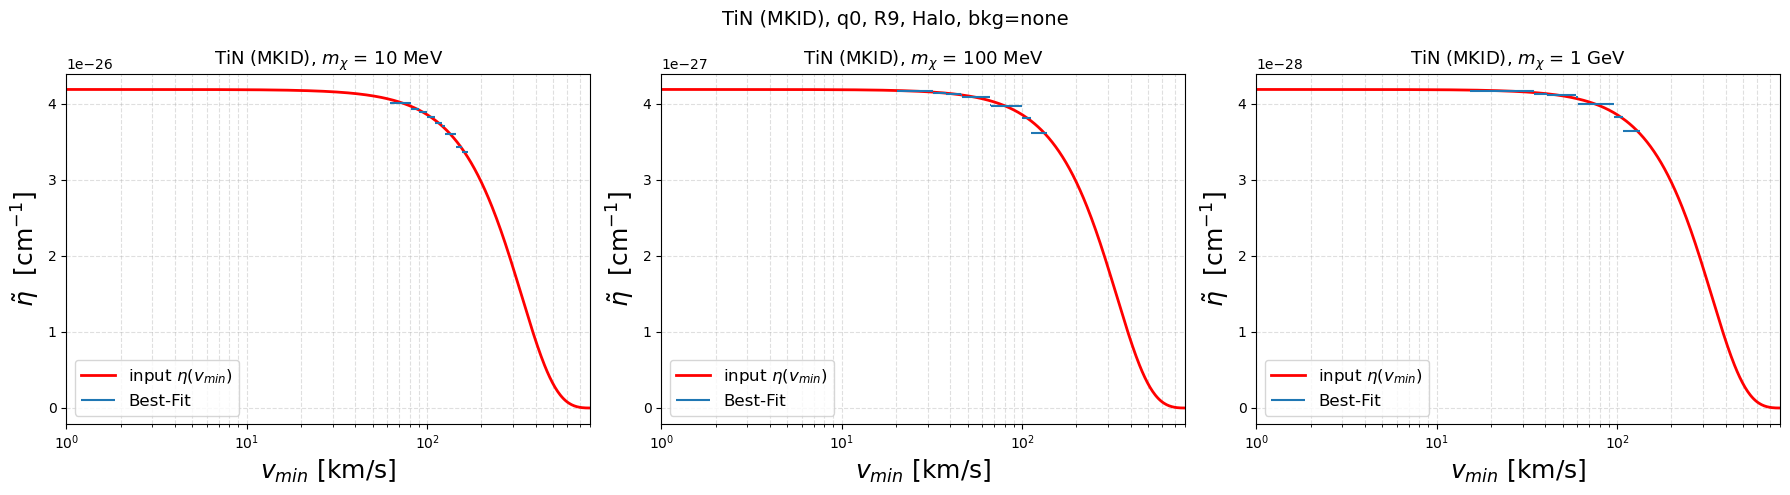

In [20]:
run_masses('TiN', q='0', nbins=9, eta='Halo')

### Light mediator (q2), 9 energy bins

signal     : [ 6112.7758042   7006.71423833  9073.60807338  7194.41968865
 12780.10657503 14669.80971044 16437.17794764 17781.56789478
 18832.45579722]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R9_Halo/flux.pdf
TiN q2 M1 R9: 9 E-bins x 335 v_min bins, peak flux 8.01e+02
signal     : [ 675.98310096  930.19003507 1166.39531837 1377.97356537 1562.78229353
 1717.97066341 1844.99488662 1942.8440089  2015.80206871]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R9_Halo/flux.pdf
TiN q2 M2 R9: 9 E-bins x 504 v_min bins, peak flux 8.46e+01
signal     : [ 69.84601451  95.21283188 118.56040067 139.43794125 157.50496987
 172.67097543 185.09099548 194.6643776  201.82627702]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_a

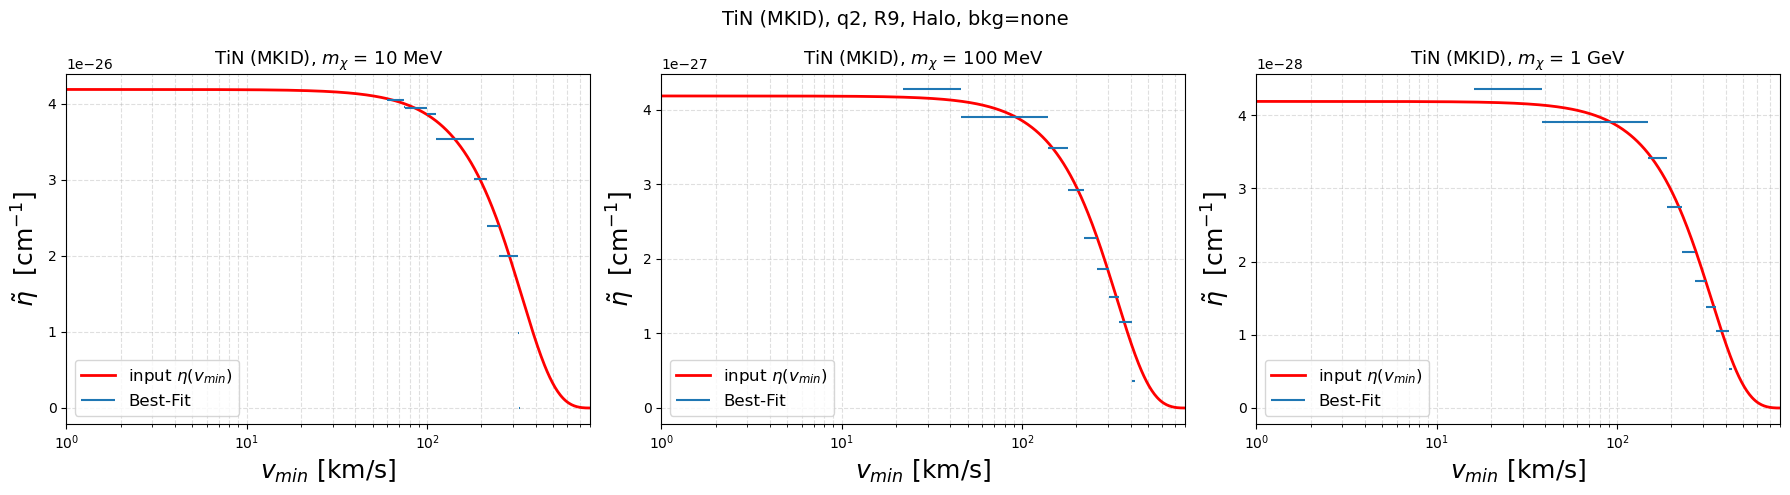

In [21]:
run_masses('TiN', q='2', nbins=9, eta='Halo')

## Mixture (best-fit) — sweep dark-disk fraction

`eta = (1-p)*Halo + p*Disk`. Each figure overlays 100% SHM (gray) and `p` x pure disk (green).

### Heavy mediator (q0), 5 energy bins

signal     : [1313.98487213 3880.13701844 5282.12846759 6451.53750845 7578.55778183]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_mix5/flux.pdf
TiN q0 M1 R5: 5 E-bins x 128 v_min bins, peak flux 8.37e+02
signal     : [121.7370751  369.45730492 526.26382773 669.74593033 795.98648061]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_mix5/flux.pdf
TiN q0 M2 R5: 5 E-bins x 141 v_min bins, peak flux 8.95e+01
signal     : [11.98111826 36.57893478 52.47347294 66.94433212 79.89655203]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_mix5/flux.pdf
TiN q0 M3 R5: 5 E-bins x 144 v_min bins, peak flux 9.00e+00


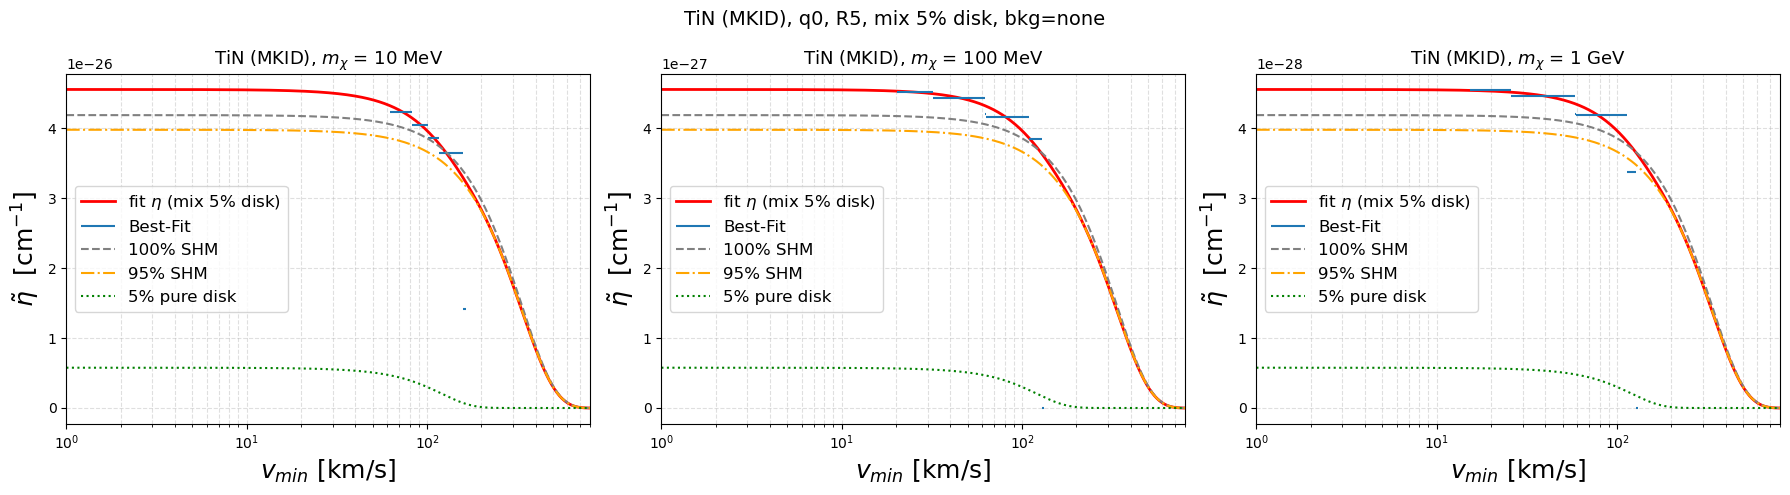

signal     : [1590.57334955 4484.17057216 5710.82976356 6484.60833829 7095.63584709]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_mix25/flux.pdf
TiN q0 M1 R5: 5 E-bins x 128 v_min bins, peak flux 1.01e+03
signal     : [159.17076439 475.5426091  656.65160695 798.30867849 894.51980031]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_mix25/flux.pdf
TiN q0 M2 R5: 5 E-bins x 141 v_min bins, peak flux 1.17e+02
signal     : [15.71519881 47.33566684 66.04321426 80.77907031 91.18626814]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_mix25/flux.pdf
TiN q0 M3 R5: 5 E-bins x 144 v_min bins, peak flux 1.19e+01


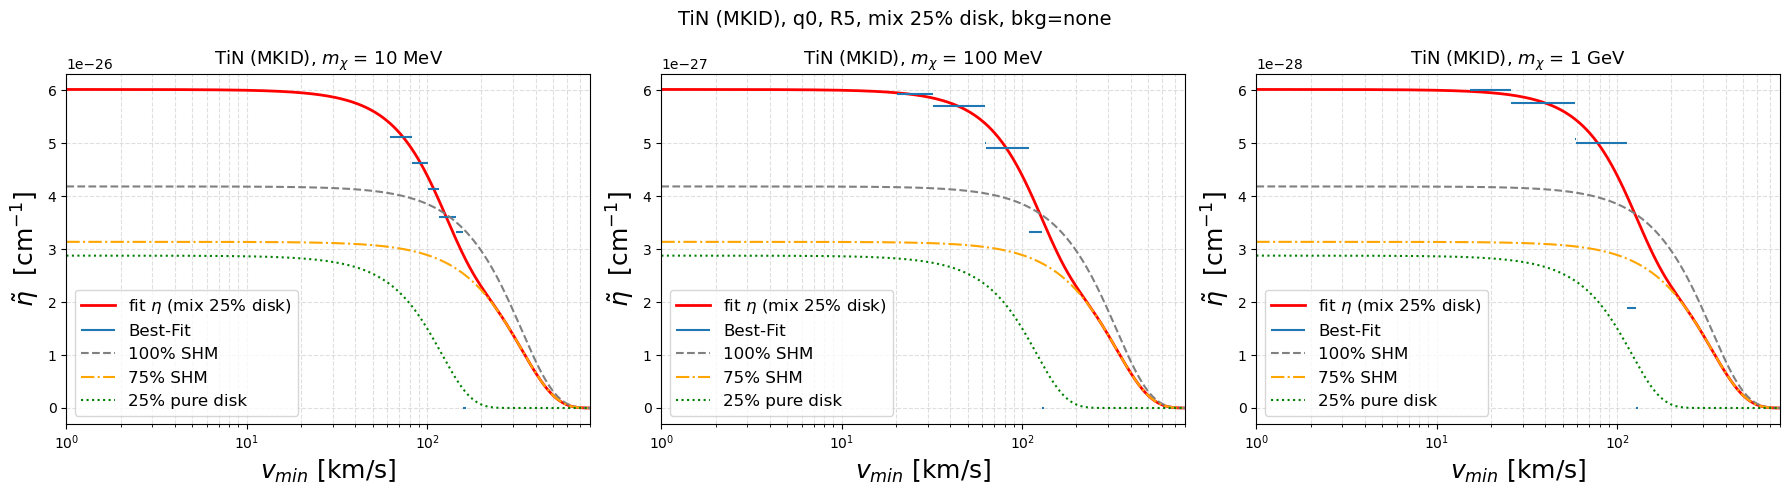

In [22]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='0', nbins=5, disk_fraction=p)

### Light mediator (q2), 5 energy bins

signal     : [ 6453.06353266 18524.54004821 22230.58527581 30247.42294238
 34358.29252919]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R5_mix5/flux.pdf
TiN q2 M1 R5: 5 E-bins x 328 v_min bins, peak flux 8.37e+02
signal     : [ 723.72980853 2122.82857299 2874.78735655 3404.1189693  3723.86508065]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R5_mix5/flux.pdf
TiN q2 M2 R5: 5 E-bins x 482 v_min bins, peak flux 9.86e+01
signal     : [ 74.74048678 215.00651664 289.90843901 342.22687497 373.69934786]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_mix5/flux.pdf
TiN q2 M3 R5: 5 E-bins x 500 v_min bins, peak flux 1.02e+01


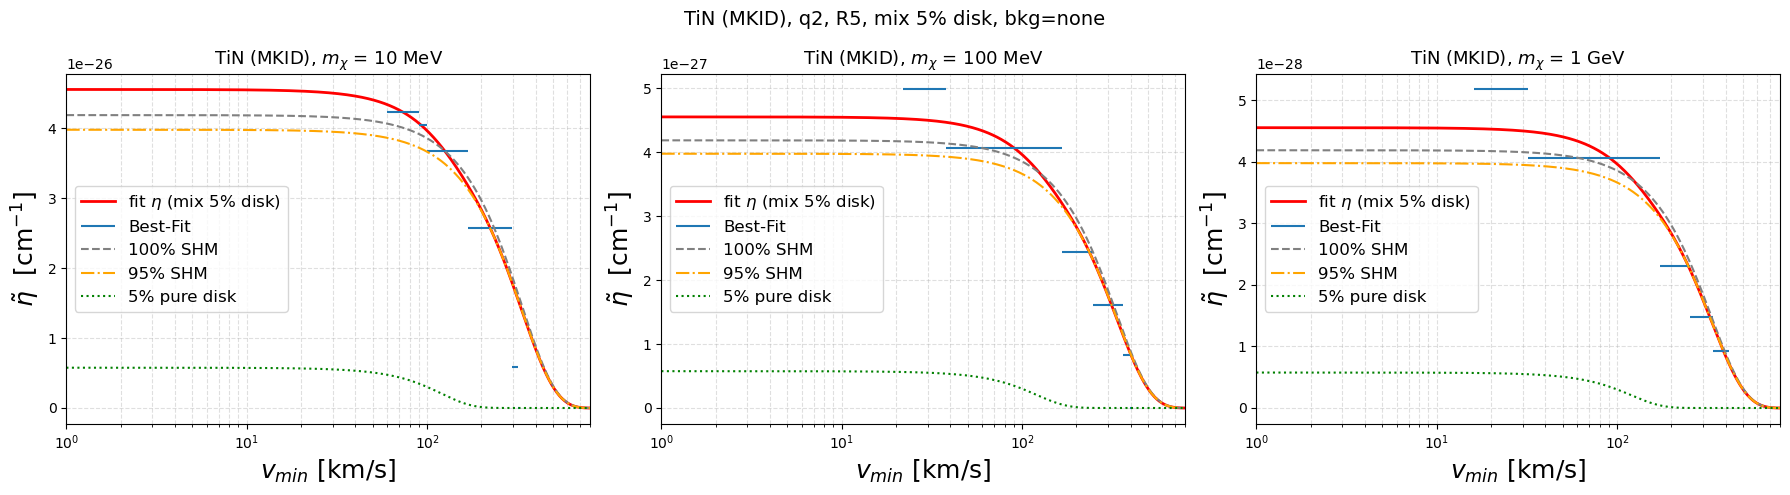

signal     : [ 7814.21444651 20712.88612373 22641.41985792 27571.48383649
 29453.0060546 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R5_mix25/flux.pdf
TiN q2 M1 R5: 5 E-bins x 328 v_min bins, peak flux 1.01e+03
signal     : [ 914.71663882 2495.20269921 3082.78725637 3387.52662266 3492.32898941]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R5_mix25/flux.pdf
TiN q2 M2 R5: 5 E-bins x 482 v_min bins, peak flux 1.41e+02
signal     : [ 94.31837587 252.93050103 312.42313132 343.31164413 353.76598569]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_mix25/flux.pdf
TiN q2 M3 R5: 5 E-bins x 500 v_min bins, peak flux 1.53e+01


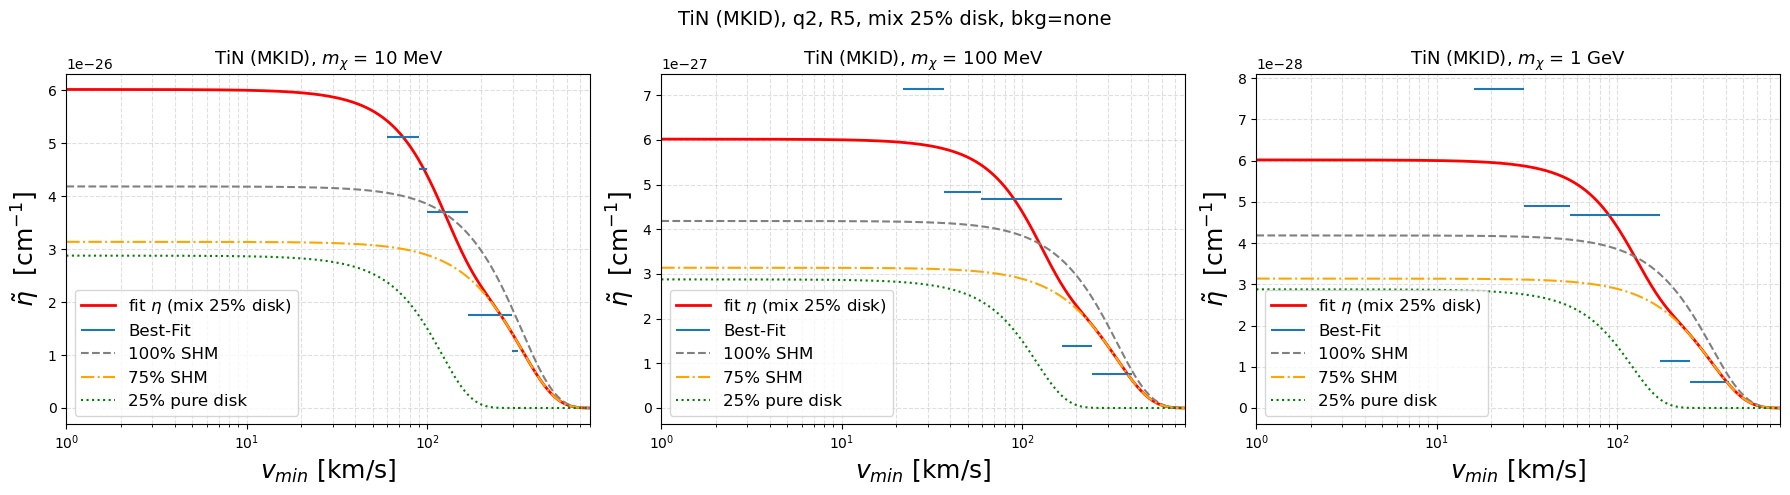

In [23]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='2', nbins=5, disk_fraction=p)

### Heavy mediator (q0), 9 energy bins

signal     : [1313.98487213 1777.70983859 2162.42384519 2523.85888586 2812.99635116
 3170.03834218 3477.03247888 3788.8148771  4064.78733555]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_mix5/flux.pdf
TiN q0 M1 R9: 9 E-bins x 132 v_min bins, peak flux 8.38e+02
signal     : [121.7370751  165.79394281 207.93734638 248.60457348 288.88762076
 326.94861998 363.31226536 397.12394542 428.45752501]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_mix5/flux.pdf
TiN q0 M2 R9: 9 E-bins x 146 v_min bins, peak flux 8.93e+01
signal     : [11.98111826 16.37236647 20.69351193 24.83076568 28.87354494 32.71408448
 36.38528853 39.80679419 43.02453224]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-non

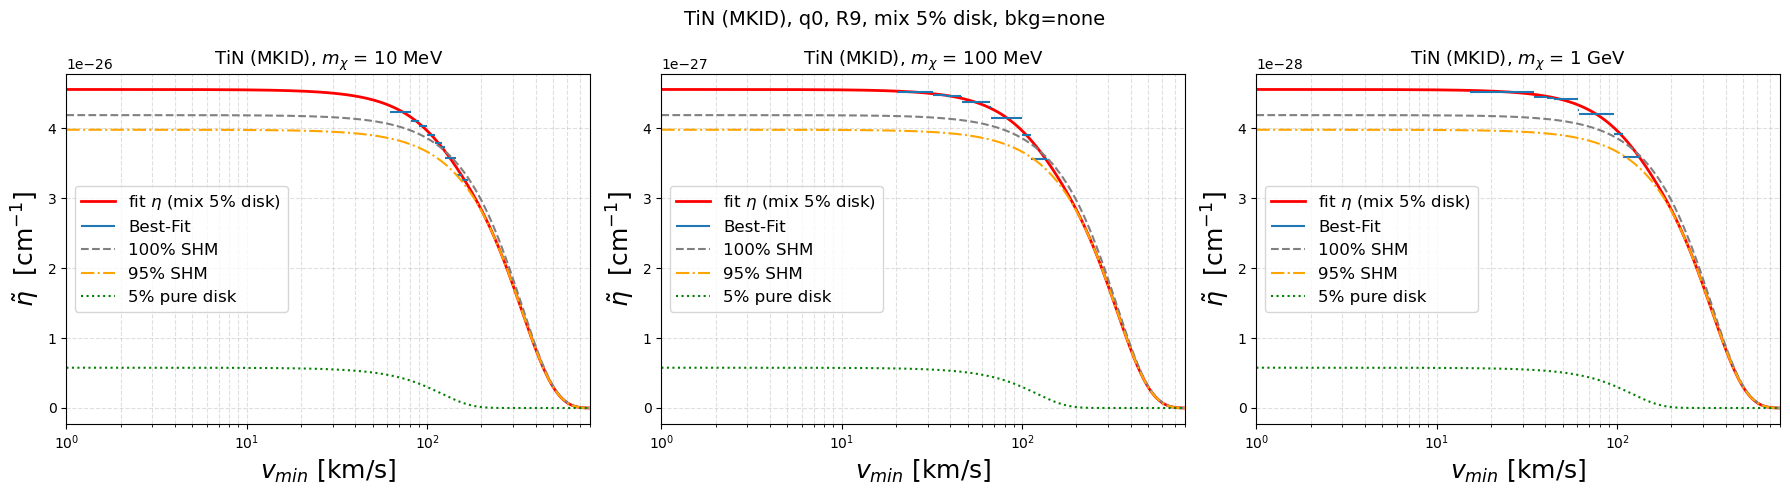

signal     : [1590.57334955 2091.93115595 2464.9121788  2782.48034938 2993.76543072
 3251.85529387 3437.99076356 3612.89949555 3748.06077428]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_mix25/flux.pdf
TiN q0 M1 R9: 9 E-bins x 132 v_min bins, peak flux 1.02e+03
signal     : [159.17076439 214.87991578 266.31457991 313.53797623 357.47413366
 395.39671483 427.89404601 454.04848714 474.3415749 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_mix25/flux.pdf
TiN q0 M2 R9: 9 E-bins x 146 v_min bins, peak flux 1.17e+02
signal     : [15.71519881 21.31595726 26.66306487 31.55938724 36.06481249 40.01549512
 43.42180847 46.1939534  48.40731322]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-n

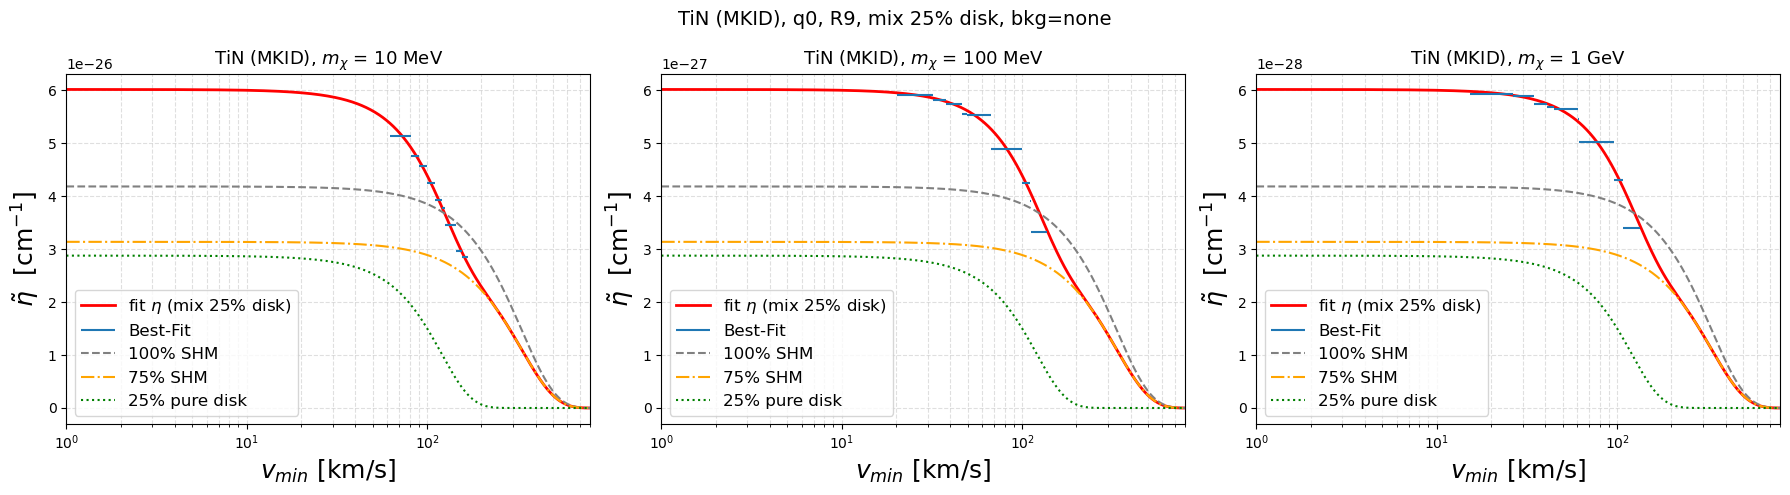

In [24]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='0', nbins=9, disk_fraction=p)

### Light mediator (q2), 9 energy bins

signal     : [ 6453.06353266  7312.78376049  9322.37159311  7348.64444147
 12742.46869743 14445.38698176 16030.56900513 17219.89899819
 18144.8703702 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R9_mix5/flux.pdf
TiN q2 M1 R9: 9 E-bins x 335 v_min bins, peak flux 8.46e+02
signal     : [ 723.72980853  981.93942943 1212.58626795 1412.75871124 1583.48555442
 1723.62573225 1835.6886977  1919.2585984  1979.1315252 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R9_mix5/flux.pdf
TiN q2 M2 R9: 9 E-bins x 504 v_min bins, peak flux 9.31e+01
signal     : [ 74.74048678 100.46037068 123.2711407  143.08477073 159.82683347
 173.55898922 184.53600186 192.71562506 198.58413073]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_a

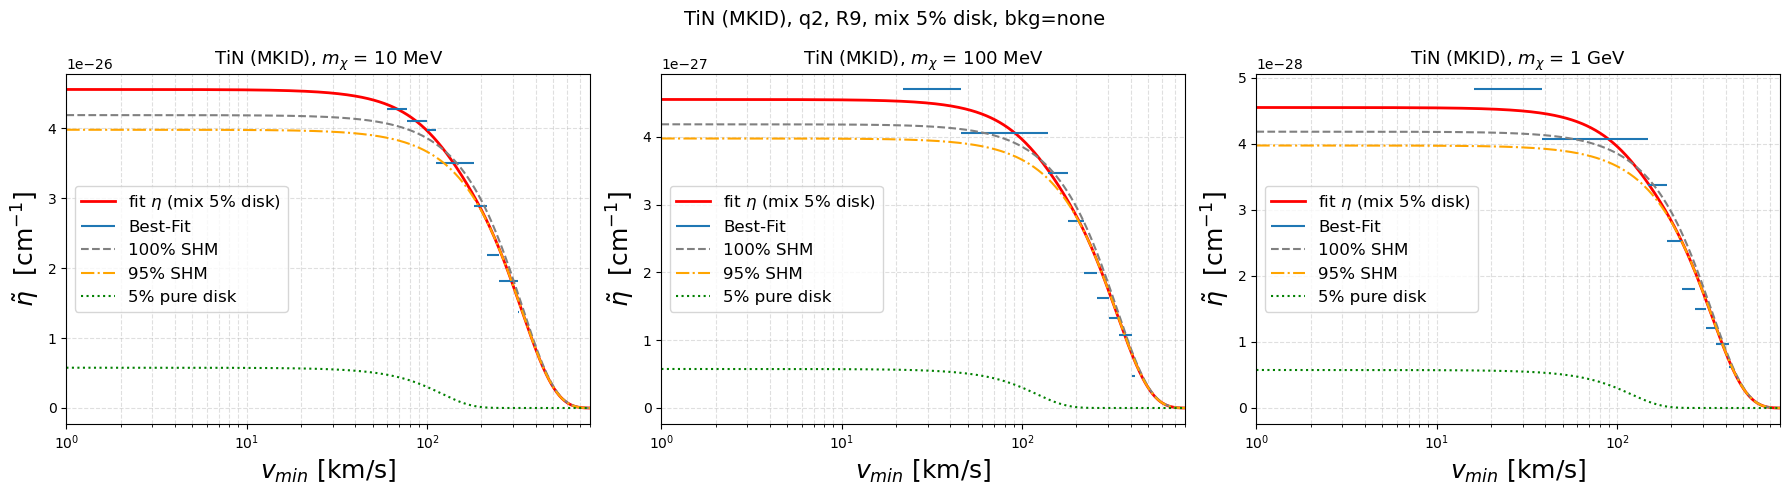

signal     : [ 7814.21444651  8537.06184911 10317.42567205  7965.54345275
 12591.917187   13547.69606703 14404.13323511 14973.22341179
 15394.52866212]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R9_mix25/flux.pdf
TiN q2 M1 R9: 9 E-bins x 335 v_min bins, peak flux 1.03e+03
signal     : [ 914.71663882 1188.93700685 1397.35006628 1551.89929469 1666.29859797
 1746.24600759 1798.46394203 1824.91695643 1832.44935117]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R9_mix25/flux.pdf
TiN q2 M2 R9: 9 E-bins x 504 v_min bins, peak flux 1.28e+02
signal     : [ 94.31837587 121.4505259  142.11410085 157.67208863 169.11428785
 177.11104434 182.31602739 184.92061488 185.61554559]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor

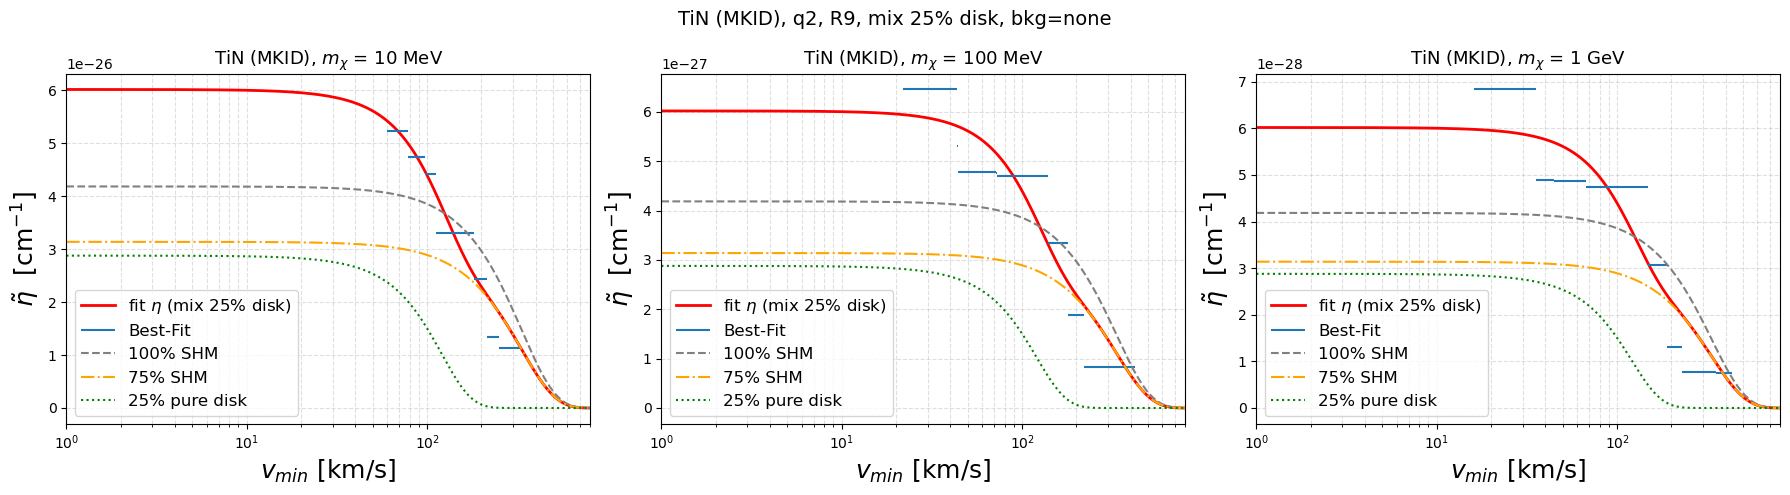

In [25]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='2', nbins=9, disk_fraction=p)

## Bound (Earth-bound thermal DM)

Dense (`rho_b = 1e14` GeV/cm^3), isotropic, cold (`v0 ~ 2.16` km/s at 1 GeV), `vesc = 11.2` km/s. Only **M3 (1 GeV)** is shown: the bound population is too slow to reach the `v_min` thresholds of the lighter masses (M1/M2 have no signal).

### Heavy mediator (q0), 5 energy bins

signal     : [11.04759812 33.88975177 49.08103761 63.48564757 77.074123  ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_Bound/flux.pdf
TiN q0 M3 R5: 5 E-bins x 144 v_min bins, peak flux 8.28e+00


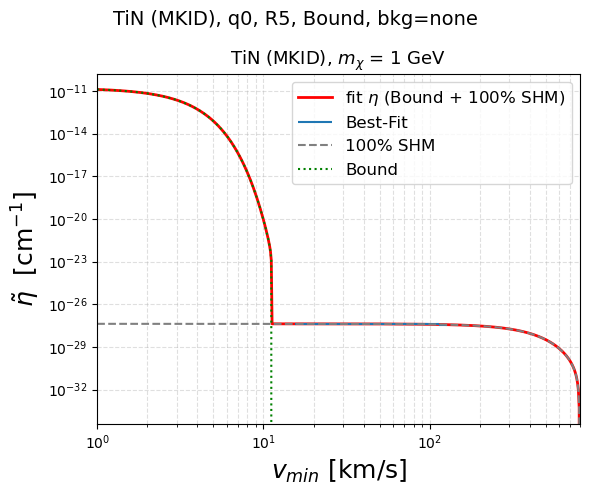

In [26]:
run_masses('TiN', q='0', nbins=5, eta='Bound', masses=('3',))

### Light mediator (q2), 5 energy bins

signal     : [ 69.84601451 205.52552054 284.27976593 341.95568268 378.6826884 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_Bound/flux.pdf
TiN q2 M3 R5: 5 E-bins x 500 v_min bins, peak flux 9.04e+00


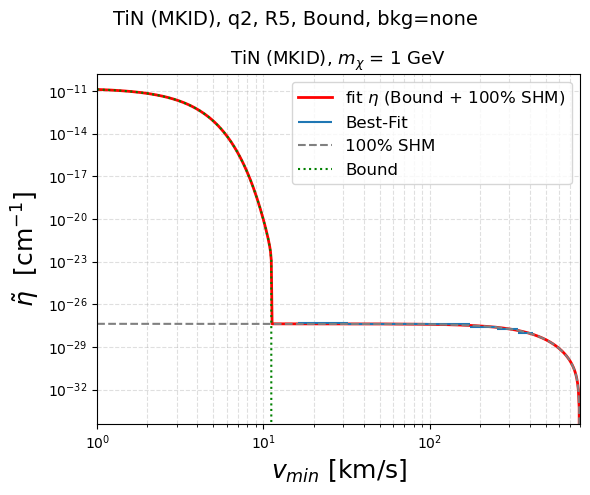

In [27]:
run_masses('TiN', q='2', nbins=5, eta='Bound', masses=('3',))

### Heavy mediator (q0), 9 energy bins

signal     : [11.04759812 15.13646878 19.2011237  23.14861029 27.07572805 30.88873182
 34.62615854 38.21000439 41.67883699]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R9_Bound/flux.pdf
TiN q0 M3 R9: 9 E-bins x 149 v_min bins, peak flux 8.25e+00


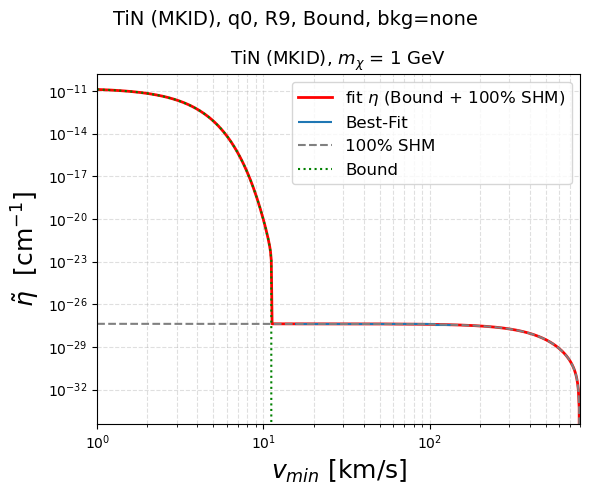

In [28]:
run_masses('TiN', q='0', nbins=9, eta='Bound', masses=('3',))

### Light mediator (q2), 9 energy bins

signal     : [ 69.84601451  95.21283188 118.56040067 139.43794125 157.50496987
 172.67097543 185.09099548 194.6643776  201.82627702]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R9_Bound/flux.pdf
TiN q2 M3 R9: 9 E-bins x 523 v_min bins, peak flux 8.61e+00


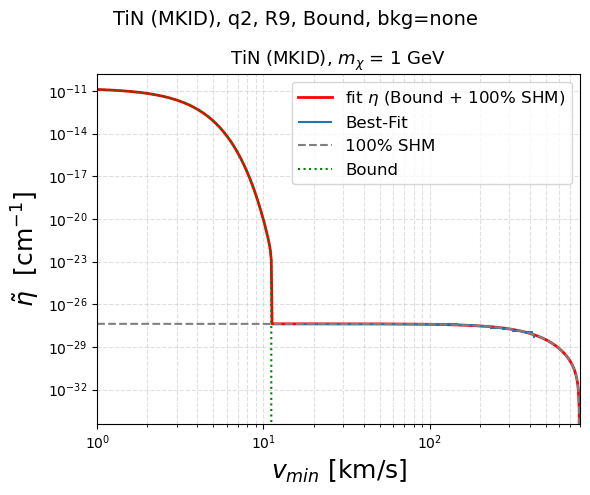

In [29]:
run_masses('TiN', q='2', nbins=9, eta='Bound', masses=('3',))